# Survivor Data Set: An Exploration
## Project Overview

We seek to understand the underlying themes in the reality TV gameshow "Survivor". The show is currently airing it's 50th season, but the gameplay we see in the later seasons is very different from the early seasons of the show. Survivor is a gameshow about physical challenges and mental strength, but fundamentally it is a show about relationships with others. In a game where the goal is to "Outwit, Outplay, Outlast", what does this actually translate to? In order to win you need the votes of the jury, which is made up of the players you had a hand in voting off of the tribe.

The thing that makes Survivor so interesting is how different every season is, and how the game is always evolving. In early seasons, loyalty and morals were valued, and the gameplay was relatively simple. As time went on, players got more conniving, and blindsides and backstabbing became the norm. But what is most interesting is that as the gameplay changed, so did the mentality of the players. Playing fair isn't enough to win anymore. 

Through this data we hope to find answers to some of these questions:
- What does it take Outwit, Outplay, and Outlast?
- What decisions to winners make? 
- What decisions do losers make?
- How have the decisions made by winners and losers changed as the game has evolved?
- Are there trends that predict performance?
- Are there qualities that predict performance?
- Have there been changes in these trends/qualities over time?

## Data Description and Source
The original survivoR dataset is in R, [original data set](https://github.com/doehm/survivoR/tree/master/data). We will be using a modified version of this dataset that has been converted to CSV files found here: [Survivor Data Set](https://github.com/rfordatascience/tidytuesday/tree/master/data/2021/2021-06-01)

The original dataset has 23 R data files, while the dataset that's been converted to CSV only has 5 of these. 

The 5 csv files are:
- Summary
- Challanges
- Castaways
- Viewers
- Jury Votes


# Initial CSV Data
The sections below walk through each CSV in the same order: **Initial CSV exploration**, **Cleaning needs**, **Methods**, and **Results**.


## Setup: imports and loading

Import **pandas**, **matplotlib** / **seaborn** for plots, **IPython.display** for styled tables, then load all tables from the TidyTuesday CSV mirror.


In [1]:
# Imports for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

In [2]:
# Each table is available as a CSV from the TidyTuesday GitHub mirror
base_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-06-01/"

# Load the main tables
summary_df     = pd.read_csv(base_url + "summary.csv")
challenges_df  = pd.read_csv(base_url + "challenges.csv")
castaways_df   = pd.read_csv(base_url + "castaways.csv")
viewers_df     = pd.read_csv(base_url + "viewers.csv")
jury_votes_df  = pd.read_csv(base_url + "jury_votes.csv")

## Table: Summary


### Initial CSV exploration

#### Relevance:
- Primary data set for information on seasons, winners, and dates.
- Useful for determining winners and trends over time.

#### Size:
- 40 rows
- 19 columns
- 6.1 KB

#### Column descriptions (English):
- **Season Name**: The name of the season
- **Season**: The season number
- **Location**: The geographical location of the show
- **Country**: The country where the season takes place
- **Tribe Setup**: How players are divided into tribes (teams)
- **Full Name**: The name of the player
- **Winner**: The winner of the season
- **Runner Ups**: Second place
- **Final Vote**: The vote split for the winner
- **Time Slot**: Day and time of week when episodes aired
- **Premiered**: Date when the season premiered
- **Ended**: Date when the season ended
- **Filming Strated**: Date when filming started (note: this spelling matches the CSV column label)
- **Filming Ended**: Date when filming ended
- **Viewers Finale**: Number of viewers for the final episode
- **Viewers Reunion**: Number of viewers for the reunion (contestant retrospective)
- **Viewers Mean**: Average viewership for episodes
- **Rank**: Viewer final ranking of the contestant

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [3]:
summary_df.info()
summary_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season_name      40 non-null     str    
 1   season           40 non-null     int64  
 2   location         40 non-null     str    
 3   country          40 non-null     str    
 4   tribe_setup      40 non-null     str    
 5   full_name        40 non-null     str    
 6   winner           40 non-null     str    
 7   runner_ups       40 non-null     str    
 8   final_vote       40 non-null     str    
 9   timeslot         40 non-null     str    
 10  premiered        40 non-null     str    
 11  ended            40 non-null     str    
 12  filming_started  40 non-null     str    
 13  filming_ended    40 non-null     str    
 14  viewers_premier  40 non-null     float64
 15  viewers_finale   40 non-null     float64
 16  viewers_reunion  40 non-null     float64
 17  viewers_mean     38 non-null 

,season_name,season,location,country,tribe_setup,full_name,winner,runner_ups,final_vote,timeslot,premiered,ended,filming_started,filming_ended,viewers_premier,viewers_finale,viewers_reunion,viewers_mean,rank
0,Survivor: Borneo,1,"Pulau Tiga, Sabah, Malaysia",Malaysia,Two tribes of eight new players,Richard Hatch,Richard,Kelly Wiglesworth,4-3,Wednesday 8:00 pm,2000-05-31,2000-08-23,2000-03-13,2000-04-20,15.51,51.69,36.70,28.30,2.0
1,Survivor: The Australian Outback,2,"Herbert River at Goshen Station, Queensland, A...",Australia,Two tribes of eight new players,Tina Wesson,Tina,Colby Donaldson,4-3,Thursday 8:00 pm,2001-01-28,2001-05-03,2000-10-23,2000-12-03,45.37,36.35,28.01,29.80,1.0
2,Survivor: Africa,3,"Shaba National Reserve, Kenya",Kenya,Two tribes of eight new players,Ethan Zohn,Ethan,Kim Johnson,5-2,Thursday 8:00 pm,2001-10-11,2002-01-10,2001-07-11,2001-08-18,23.84,27.26,19.05,20.69,8.0
3,Survivor: Marquesas,4,"Nuku Hiva, Marquesas Islands, French Polynesia",Polynesia,Two tribes of eight new players,Vecepia Towery,Vecepia,Neleh Dennis,4-3,Thursday 8:00 pm,2002-02-28,2002-05-19,2001-11-12,2001-12-20,23.19,25.87,19.05,20.77,6.0
4,Survivor: Thailand,5,"Ko Tarutao, Satun Province, Thailand",Thailand,Two tribes of eight new players; picked by the...,Brian Heidik,Brian,Clay Jordan,4-3,Thursday 8:00 pm,2002-09-19,2002-12-19,2002-06-10,2002-07-18,23.05,24.08,20.43,21.21,4.0


### Cleaning

All steps use `clean_summary_df`, created with `summary_df.copy()` in the first cleaning code cell, so `summary_df` stays the untouched load. From raw inspection, we fix:

- `premiered`, `ended`, `filming_started`, and `filming_ended`: strings → datetimes
- `timeslot`: split into `weekday` and `air_time`
- `viewers_mean` and `rank`: median fill for `viewers_mean` and missing `rank` kept with `has_rank` for training filters


### Methods

The following code cells implement the cleaning steps on `clean_summary_df`.


In [4]:
# Working copy for cleaning; summary_df remains the raw CSV load
clean_summary_df = summary_df.copy()

In [5]:
# View the timeslot column entries
clean_summary_df['timeslot'].value_counts()

timeslot
Wednesday 8:00 pm    21
Thursday 8:00 pm     19
Name: count, dtype: int64

In [6]:
# Extract weekday and time text from timeslot
parts = clean_summary_df["timeslot"].str.extract(r"(\w+)\s+(.+)")
clean_summary_df["weekday"] = parts[0]
clean_summary_df["air_time_raw"] = parts[1]

# Parse time text into a time value
clean_summary_df["air_time"] = pd.to_datetime(
    clean_summary_df["air_time_raw"].str.strip().str.lower(),
    format="%I:%M %p",
    errors="coerce"
).dt.time

# Drop the timeslot column and airtime_raw column
clean_summary_df = clean_summary_df.drop(columns=["timeslot", "air_time_raw"])

clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season_name      40 non-null     str    
 1   season           40 non-null     int64  
 2   location         40 non-null     str    
 3   country          40 non-null     str    
 4   tribe_setup      40 non-null     str    
 5   full_name        40 non-null     str    
 6   winner           40 non-null     str    
 7   runner_ups       40 non-null     str    
 8   final_vote       40 non-null     str    
 9   premiered        40 non-null     str    
 10  ended            40 non-null     str    
 11  filming_started  40 non-null     str    
 12  filming_ended    40 non-null     str    
 13  viewers_premier  40 non-null     float64
 14  viewers_finale   40 non-null     float64
 15  viewers_reunion  40 non-null     float64
 16  viewers_mean     38 non-null     float64
 17  rank             38 non-null 

In [7]:
# Convert the premiered, ended, filming_started, and filming_ended columns to datetime
clean_summary_df['premiered'] = pd.to_datetime(clean_summary_df['premiered'])
clean_summary_df['ended'] = pd.to_datetime(clean_summary_df['ended'])
clean_summary_df['filming_started'] = pd.to_datetime(clean_summary_df['filming_started'])
clean_summary_df['filming_ended'] = pd.to_datetime(clean_summary_df['filming_ended'])

# Show the updated dataframe
clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season_name      40 non-null     str           
 1   season           40 non-null     int64         
 2   location         40 non-null     str           
 3   country          40 non-null     str           
 4   tribe_setup      40 non-null     str           
 5   full_name        40 non-null     str           
 6   winner           40 non-null     str           
 7   runner_ups       40 non-null     str           
 8   final_vote       40 non-null     str           
 9   premiered        40 non-null     datetime64[us]
 10  ended            40 non-null     datetime64[us]
 11  filming_started  40 non-null     datetime64[us]
 12  filming_ended    40 non-null     datetime64[us]
 13  viewers_premier  40 non-null     float64       
 14  viewers_finale   40 non-null     float64       
 15  vi

In [8]:
# View the null values in viewers_mean and rank
clean_summary_df[clean_summary_df['viewers_mean'].isna() | clean_summary_df['rank'].isna()]

,season_name,season,location,country,tribe_setup,full_name,winner,runner_ups,final_vote,premiered,ended,filming_started,filming_ended,viewers_premier,viewers_finale,viewers_reunion,viewers_mean,rank,weekday,air_time
38,Survivor: Island of the Idols,39,"Mamanuca Islands, Fiji",Fiji,Two tribes of ten new players. Past winners Ro...,Tommy Sheehan,Tommy,"Dean Kowalski, Noura Salman",8-2-0,2019-09-25,2019-12-18,2019-03-21,2019-04-28,6.29,6.52,4.61,NaN,NaN,Wednesday,20:00:00
39,Survivor: Winners at War,40,"Mamanuca Islands, Fiji",Fiji,Two tribes of ten winners of past Survivor sea...,Tony Vlachos,Tony,"Natalie Anderson, Michele Fitzgerald",12-4-0,2020-02-12,2020-05-13,2019-05-22,2019-06-29,6.68,7.94,4.61,NaN,NaN,Wednesday,20:00:00


`rank` and `viewers_mean` are missing in the same two rows. We keep every season, so `viewers_mean` is filled with the median of non-missing values, `rank` stays NaN where unknown, and `has_rank` is True only when `rank` is present so rows without a label can be excluded when training a model that predicts `rank`.

In [9]:
# Median impute viewers_mean; keep missing rank and flag rows usable as labeled training data
viewers_median = clean_summary_df["viewers_mean"].median()
clean_summary_df["viewers_mean"] = clean_summary_df["viewers_mean"].fillna(
    viewers_median
)
clean_summary_df["has_rank"] = clean_summary_df["rank"].notna()

clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season_name      40 non-null     str           
 1   season           40 non-null     int64         
 2   location         40 non-null     str           
 3   country          40 non-null     str           
 4   tribe_setup      40 non-null     str           
 5   full_name        40 non-null     str           
 6   winner           40 non-null     str           
 7   runner_ups       40 non-null     str           
 8   final_vote       40 non-null     str           
 9   premiered        40 non-null     datetime64[us]
 10  ended            40 non-null     datetime64[us]
 11  filming_started  40 non-null     datetime64[us]
 12  filming_ended    40 non-null     datetime64[us]
 13  viewers_premier  40 non-null     float64       
 14  viewers_finale   40 non-null     float64       
 15  vi

### Results

**Summary:** Summary Data Frame

`clean_summary_df` keeps all 40 seasons with consistent dtypes and `weekday` / `air_time` from `timeslot`. After cleaning, `viewers_mean` has no nulls, from median imputation; `rank` is still null for the two incomplete seasons, so `has_rank` marks rows to include when `rank` is a target.


## Table: Challenges


### Initial CSV exploration

#### Relevance:
- Examines outcomes when contestants and tribes compete; these outcomes influence decisions when tribes vote contestants out.

#### Size:
- 5023 rows
- 8 columns
- 314.1 KB

#### Column descriptions (English):
- **season_name**: The season's name
- **season**: The season number
- **episode**: The episode number within the season
- **title**: The title of the episode
- **day**: The running day count since the game began
- **challenge_type**: Reward (a prize) or immunity (protection from being voted out)
- **winners**: The name of the contestant who won the challenge
- **winning_tribe**: The name of the tribe that won the challenge

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [10]:
print(challenges_df.info())
print(challenges_df.head())

# Challenge nulls before cleaning
challenge_nulls_before = challenges_df[["winners", "winning_tribe"]].isna().sum()
print("Nulls before cleaning:")
print(challenge_nulls_before)

<class 'pandas.DataFrame'>
RangeIndex: 5023 entries, 0 to 5022
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   season_name     5023 non-null   str  
 1   season          5023 non-null   int64
 2   episode         5023 non-null   int64
 3   title           5023 non-null   str  
 4   day             5023 non-null   int64
 5   challenge_type  5023 non-null   str  
 6   winners         5006 non-null   str  
 7   winning_tribe   3992 non-null   str  
dtypes: int64(3), str(5)
memory usage: 314.1 KB
None
                season_name  season  episode                   title  day  \
0  Survivor: Winners at War      40        1  Greatest of the Greats    2   
1  Survivor: Winners at War      40        1  Greatest of the Greats    2   
2  Survivor: Winners at War      40        1  Greatest of the Greats    2   
3  Survivor: Winners at War      40        1  Greatest of the Greats    2   
4  Survivor: Winners at War      40  

### Cleaning Needs / Methods

The following code cell houses all the challenge-row cleaning rules for `challenges_df`.


In [11]:
# Clean Version
challenges_cleaned_df = challenges_df.copy()

# Dropping rows that are placeholder / non-challenge rows
drop_mask = (
    # Survivor: Island of the Idols, episode 12
    ((challenges_cleaned_df["season"] == 39) &
     (challenges_cleaned_df["episode"] == 12) &
     (challenges_cleaned_df["day"] == 36) &
     (challenges_cleaned_df["challenge_type"] == "immunity") &
     (challenges_cleaned_df["winners"].isna())) |

    # Survivor: David vs. Goliath, episode 4
    ((challenges_cleaned_df["season"] == 37) &
     (challenges_cleaned_df["episode"] == 4) &
     (challenges_cleaned_df["day"] == 10) &
     (challenges_cleaned_df["challenge_type"] == "immunity") &
     (challenges_cleaned_df["winners"].isna()))
)

challenges_cleaned_df = challenges_cleaned_df.loc[~drop_mask].copy()

# Filling in rows where there truly was no immunity winner
no_winner_cases = [
    (32, 13),  # Kaoh Rong (Joe evacuated)
    (24, 6),   # One World (Colton evacuated)
    (21, 12),  # Nicaragua (NaOnka and Kelly quit)
    (19, 6),   # Samoa (Russell Swan evacuated)
    (12, 11),  # Panama (Bruce evacuated)
    (8, 3),    # All-Stars (Jenna quit)
    (8, 6),    # All-Stars (Sue quit)
    (2, 6)     # Australian Outback (Michael evacuated)
]

for season_num, episode_num in no_winner_cases:
    mask = (
        (challenges_cleaned_df["season"] == season_num) &
        (challenges_cleaned_df["episode"] == episode_num) &
        (challenges_cleaned_df["challenge_type"] == "immunity") &
        (challenges_cleaned_df["winners"].isna())
    )

    challenges_cleaned_df.loc[mask, "winners"] = "No challenge winner"
    challenges_cleaned_df.loc[mask, "winning_tribe"] = "Not applicable"

# If a winner exists but winning_tribe is missing, then tribe winner does not apply
tribe_not_applicable_mask = (
    challenges_cleaned_df["winners"].notna() &
    challenges_cleaned_df["winning_tribe"].isna()
)

challenges_cleaned_df.loc[tribe_not_applicable_mask, "winning_tribe"] = "Not applicable"

# Fixing Survivor: Blood vs. Water, episode 1
# Galang won the combined immunity/reward challenge, so restore the missing immunity winners
bvw_bad_immunity_rows = (
    (challenges_cleaned_df["season"] == 27) &
    (challenges_cleaned_df["episode"] == 1) &
    (challenges_cleaned_df["day"] == 1) &
    (challenges_cleaned_df["challenge_type"] == "immunity") &
    (challenges_cleaned_df["winners"].isna())
)

challenges_cleaned_df = challenges_cleaned_df.loc[~bvw_bad_immunity_rows].copy()

galang_members = [
    "Aras",
    "Colton",
    "Gervase",
    "Kat",
    "Laura B.",
    "Laura M.",
    "Monica",
    "Tina",
    "Tyson"
]

bvw_immunity_rows = pd.DataFrame(
    [
        {
            "season_name": "Survivor: Blood vs. Water",
            "season": 27,
            "episode": 1,
            "title": "Blood Is Thicker Than Anything",
            "day": 1,
            "challenge_type": "immunity",
            "winners": member,
            "winning_tribe": "Galang"
        }
        for member in galang_members
    ]
)

challenges_cleaned_df = pd.concat(
    [challenges_cleaned_df, bvw_immunity_rows],
    ignore_index=True
)

# Drop the last 3 blank reward placeholder rows
final_placeholder_rows = (
    ((challenges_cleaned_df["season"] == 22) &
     (challenges_cleaned_df["episode"] == 14) &
     (challenges_cleaned_df["day"] == 38) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna())) |

    ((challenges_cleaned_df["season"] == 16) &
     (challenges_cleaned_df["episode"] == 1) &
     (challenges_cleaned_df["day"] == 3) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna())) |

    ((challenges_cleaned_df["season"] == 13) &
     (challenges_cleaned_df["episode"] == 6) &
     (challenges_cleaned_df["day"] == 15) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna()))
)

challenges_cleaned_df = challenges_cleaned_df.loc[~final_placeholder_rows].copy()

# Sort the cleaned df so the column names make sense
challenges_cleaned_df = challenges_cleaned_df.sort_values(
    by=["season", "episode", "day", "challenge_type", "winners"]
).reset_index(drop=True)

# Challenge nulls after cleaning
challenge_nulls_after = challenges_cleaned_df[["winners", "winning_tribe"]].isna().sum()
print("\nChallenge nulls after cleaning:")
print(challenge_nulls_after)

print(challenges_cleaned_df.info())
print(challenges_cleaned_df.head())


Challenge nulls after cleaning:
winners          0
winning_tribe    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5024 entries, 0 to 5023
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   season_name     5024 non-null   str  
 1   season          5024 non-null   int64
 2   episode         5024 non-null   int64
 3   title           5024 non-null   str  
 4   day             5024 non-null   int64
 5   challenge_type  5024 non-null   str  
 6   winners         5024 non-null   str  
 7   winning_tribe   5024 non-null   str  
dtypes: int64(3), str(5)
memory usage: 314.1 KB
None
        season_name  season  episode          title  day challenge_type  \
0  Survivor: Borneo       1        1  The Marooning    3       immunity   
1  Survivor: Borneo       1        1  The Marooning    3       immunity   
2  Survivor: Borneo       1        1  The Marooning    3       immunity   
3  Survivor: Borneo       1        1  

### Results

See the printed null counts and `challenges_cleaned_df.info()` / `head()` output above for this run.


## Table: Castaways


### Initial CSV exploration

#### Relevance:
- Personal data on each contestant and their performance.
- Useful for analyzing how traits relate to outcomes.

#### Size:
- 744 rows
- 18 columns
- 104.8 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **full_name**: The contestant's full name
- **castaway**: The castaway's (contestant's) first name
- **age**: The contestant's age
- **city**: The city the contestant is from
- **state**: The state the contestant is from
- **personality_type**: Their personality description
- **day**: The day of the season (running count)
- **order**: Finish order for the season (larger values mean the contestant lasted longer)
- **result**: When they were voted out (string description of the order column)
- **jury_status**: If and when the player made the jury
- **original_tribe**: The tribe they started on
- **swapped_tribe**: The tribe they swapped to
- **swapped_tribe2**: The tribe they swapped to a second time
- **merged_tribe**: The merged tribe name
- **total_votes_received**: Number of votes cast against the contestant
- **immunity_idols_won**: Number of immunity idols won by the contestant

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [12]:
castaways_df.info()
castaways_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   season_name           744 non-null    str  
 1   season                744 non-null    int64
 2   full_name             744 non-null    str  
 3   castaway              744 non-null    str  
 4   age                   744 non-null    int64
 5   city                  744 non-null    str  
 6   state                 744 non-null    str  
 7   personality_type      741 non-null    str  
 8   day                   744 non-null    int64
 9   order                 744 non-null    int64
 10  result                744 non-null    str  
 11  jury_status           339 non-null    str  
 12  original_tribe        742 non-null    str  
 13  swapped_tribe         460 non-null    str  
 14  swapped_tribe2        61 non-null     str  
 15  merged_tribe          444 non-null    str  
 16  total_votes_receive

,season_name,season,full_name,castaway,age,city,state,personality_type,day,order,result,jury_status,original_tribe,swapped_tribe,swapped_tribe2,merged_tribe,total_votes_received,immunity_idols_won
0,Survivor: Winners at War,40,Natalie Anderson,Natalie,33,Edgewater,New Jersey,ESTP,2,1,1st voted out,NaN,Sele,NaN,NaN,NaN,11,1
1,Survivor: Winners at War,40,Amber Mariano,Amber,40,Pensacola,Florida,ISFP,3,2,2nd voted out,1st jury member,Dakal,NaN,NaN,NaN,6,0
2,Survivor: Winners at War,40,Danni Boatwright,Danni,43,Shawnee,Kansas,ENFJ,6,3,3rd voted out,2nd jury member,Sele,NaN,NaN,NaN,8,0
3,Survivor: Winners at War,40,Ethan Zohn,Ethan,45,Hillsborough,New Hampshire,ISFP,9,4,4th voted out,3rd jury member,Sele,NaN,NaN,NaN,4,0
4,Survivor: Winners at War,40,Tyson Apostol,Tyson,39,Mesa,Arizona,ESTP,11,5,5th voted out,NaN,Dakal,NaN,NaN,NaN,12,0


#### Raw inspection (continued)

The following information is used to determine the basic information about the dataset that is needed, and explained at the top of this section.


In [13]:
# Shape and column names
print("SHAPE")
print(castaways_df.shape)

print("\nCOLUMNS")
print(castaways_df.columns.tolist())

# Data types
print("\nDATA TYPES")
print(castaways_df.dtypes)

# Missing values
print("\nMISSING VALUES")
print(castaways_df.isnull().sum())


SHAPE
(744, 18)

COLUMNS
['season_name', 'season', 'full_name', 'castaway', 'age', 'city', 'state', 'personality_type', 'day', 'order', 'result', 'jury_status', 'original_tribe', 'swapped_tribe', 'swapped_tribe2', 'merged_tribe', 'total_votes_received', 'immunity_idols_won']

DATA TYPES
season_name               str
season                  int64
full_name                 str
castaway                  str
age                     int64
city                      str
state                     str
personality_type          str
day                     int64
order                   int64
result                    str
jury_status               str
original_tribe            str
swapped_tribe             str
swapped_tribe2            str
merged_tribe              str
total_votes_received    int64
immunity_idols_won      int64
dtype: object

MISSING VALUES
season_name               0
season                    0
full_name                 0
castaway                  0
age                       0
ci

### Cleaning needs

#### Data cleaning: Fixing null values

Based on the above cell we find the following columns have null values:
| Column Name | Null Count |
|--------|-----------|
| personality_type | 3 |
| jury_status | 405 |
| original_tribe | 2 |
| swapped_tribe | 284 |
| swapped_tribe2 | 683 |
| merged_tribe | 300 |


### Methods

The following code cells implement the castaways cleaning steps on `clean_castaways_df`.


In [14]:
#first we create a copy of the dataframe for editing
clean_castaways_df = castaways_df.copy()

#### personality_type
First we will fix the missing personality types. Since we are only missing three, we could just drop these rows, but we may want other information on these players, so we will fill them with 'UNKNOWN' instead.

In [15]:
print(f"Before: \n")
print(clean_castaways_df['personality_type'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: personality_type
Non-Null Count  Dtype
--------------  -----
741 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [16]:
print(clean_castaways_df['personality_type'].unique())
clean_castaways_df['personality_type'] = clean_castaways_df['personality_type'].fillna('UNKNOWN')

<StringArray>
['ESTP', 'ISFP', 'ENFJ', 'ESTJ', 'INTJ', 'INFJ', 'ENTP', 'ESFP', 'ENTJ',
 'ISTP', 'ENFP', 'ESFJ', 'INTP', 'INFP',    nan, 'ISFJ', 'ISTJ']
Length: 17, dtype: str


In [17]:
print("After: \n")
print(clean_castaways_df['personality_type'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: personality_type
Non-Null Count  Dtype
--------------  -----
744 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


#### jury_status

In [18]:
# See all unique values in the column
print(f"Before: \n")
print(clean_castaways_df['jury_status'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: jury_status
Non-Null Count  Dtype
--------------  -----
339 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [19]:
print(castaways_df['jury_status'].unique())

<StringArray>
[               nan,  '1st jury member',  '2nd jury member',
  '3rd jury member',  '4th jury member',  '5th jury member',
  '6th jury member',  '7th jury member',  '8th jury member',
  '9th jury member', '10th jury member', '11th jury member',
 '12th jury member', '13th jury member', '14th jury member',
 '15th jury member', '16th jury member']
Length: 17, dtype: str


After viewing this we can understand that this column tells us what member of the jury a castaway is. The players eliminated earlier in the season don't make it on the jury, which explains why there are so many null values. After some consideration we will replace all null values with "non jury member" to follow the naming convention. 

In [20]:
clean_castaways_df['jury_status'] = clean_castaways_df['jury_status'].fillna('non jury member')

In [21]:
print("After: \n")
print(clean_castaways_df['jury_status'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: jury_status
Non-Null Count  Dtype
--------------  -----
744 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


#### original_tribe
Since there are only two null values in this column, we will investigate which two castaways have the null values to determine if we should drop the rows or replace the null with a value.

In [22]:
print(f"Before: \n")
print(clean_castaways_df['original_tribe'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: original_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [23]:
#output the two null rows
print(castaways_df[castaways_df['original_tribe'].isnull()])

         season_name  season       full_name  castaway  age     city  \
574  Survivor: Palau      10  Jonathan Libby  Jonathan   23   Dallas   
575  Survivor: Palau      10     Wanda Shirk     Wanda   55  Ulysses   

            state personality_type  day  order      result jury_status  \
574         Texas             ISTP    2      1  Eliminated         NaN   
575  Pennsylvania             ENFP    2      2  Eliminated         NaN   

    original_tribe swapped_tribe swapped_tribe2 merged_tribe  \
574            NaN           NaN            NaN          NaN   
575            NaN           NaN            NaN          NaN   

     total_votes_received  immunity_idols_won  
574                     0                   0  
575                     0                   0  


After some googling I found this explanation from a Reddit post: "For those of you who don’t know, in the very first episode of Palau (Season 10), Jonathan Libby and Wanda Shirk were eliminated before tribes were even officially formed." Based on this we can conclude that we can drop these rows from the dataframe since they are inconsequential to understanding themes in the show. 

In [24]:
clean_castaways_df = clean_castaways_df.dropna(subset=['original_tribe'])


In [25]:
print("After: \n")
clean_castaways_df['original_tribe'].info()

After: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: original_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB


#### swapped_tribe, swapped_tribe2
We will handle swapped_tribe and swapped_tribe2 together since they contain the same type of information, but some castaways swap tribes once, twice, or never.

In [26]:
print(f"Before: \n")
print(clean_castaways_df['swapped_tribe'].info())
print(clean_castaways_df['swapped_tribe2'].info())

Before: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: swapped_tribe
Non-Null Count  Dtype
--------------  -----
460 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB
None
<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: swapped_tribe2
Non-Null Count  Dtype
--------------  -----
61 non-null     str  
dtypes: str(1)
memory usage: 11.6 KB
None


In [27]:
print(clean_castaways_df['swapped_tribe'].unique())
print(clean_castaways_df['swapped_tribe2'].unique())

<StringArray>
[           nan,         'Yara',         'Sele',        'Dakal',
        'Lairo',        'Vokai',         'Lesu',         'Manu',
         'Kama',         'Vuku',       'Jabeni',         'Tiva',
       'Naviti',       'Malolo',         'Levu',         'Soko',
         'Yawa',         'Mana',         'Nuku',        'Tavua',
        'Vanua',       'Takali',      'Ikabula',       'Gondol',
     'Chan Loh',       'Angkor',        'Bayon',       'Ta Keo',
     'Nagarote',     'Escameca',       'Coyopa',      'Hunahpu',
       'Solana',       'Aparri',       'Galang',      'Tadhana',
        'Bikal',         'Gota',      'Kalabaw',      'Tandang',
       'Manono',       'Salani',       'Espada',      'La Flor',
         'Fang',         'Kota',      'Malakal',        'Airai',
      'Zhan Hu',     'Fei Long',         'Ravu',         'Moto',
     'Aitutaki',    'Rarotonga',       'Casaya',      'La Mina',
        'Nakúm',        'Yaxhá',        'Yasur',       'Lopevi',
    'Mogo M

From this output and some general knowledge, we can understand that these columns tell us what tribe a castaway switched to. However, not all players switch tribes, and especially most players don't switch tribes twice, but they are still important to the story the data is telling us. We will fill these with "Not Applicable".

In [28]:
swap_columns = ['swapped_tribe', 'swapped_tribe2']
clean_castaways_df[swap_columns] = clean_castaways_df[swap_columns].fillna('Not Applicable')

In [29]:
print("After: \n")
clean_castaways_df[swap_columns].info()

After: 

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   swapped_tribe   742 non-null    str  
 1   swapped_tribe2  742 non-null    str  
dtypes: str(2)
memory usage: 17.4 KB


#### merged_tribe

In [30]:
print(f"Before: \n")
print(clean_castaways_df['merged_tribe'].info())

Before: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: merged_tribe
Non-Null Count  Dtype
--------------  -----
444 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB
None


In [31]:
print(clean_castaways_df['merged_tribe'].unique())
print(f"Number of merged tribe names: {clean_castaways_df['merged_tribe'].nunique()}")

<StringArray>
[           nan,         'Koru',     'Lumuwaku',         'Vata',
     'Kalokalo',       'Lavita',       'Solewa',    'Maku Maku',
       'Vinaka',         'Dara',        'Orkun',       'Merica',
       'Huyopa',    'Solarrion',       'Kasama',    'Enil Edam',
    'Dangrayne',      'Tikiano',      'Te Tuna',     'Murlonio',
     'Libertad',     'Yin Yang',         'Aiga',        'Forza',
        'Nobag',         'Dabu',  'Hae Da Fung',    'Bula Bula',
    'Aitutonga',      'Gitanos',       'Xhakúm',        'Koror',
       'Alinta', 'Chaboga Mogo',       'Balboa',       'Jacaré',
    'Chuay Jai',     'Soliantu',    'Moto Maji',   'Barramundi',
      'Rattana']
Length: 41, dtype: str
Number of merged tribe names: 40


After viewing this list of the merged tribe names we now understand that this column represents the name of the merged tribe a castaway was in. Part way through the season all of the tribes get merged into one tribe, and they create a new name for the tribe. Since around half of the players each season get eliminated before the merge, said players have null values. We will fill this with 'Not Applicable' since we still want the data on the players who don't make it to the merge.

In [32]:
clean_castaways_df['merged_tribe'] = clean_castaways_df['merged_tribe'].fillna('Not Applicable')

In [33]:
print("After: \n")
clean_castaways_df['merged_tribe'].info()

After: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: merged_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB


### Results


#### The data for the Castaways dataframe is now cleaned.

In [34]:
clean_castaways_df.info()

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   season_name           742 non-null    str  
 1   season                742 non-null    int64
 2   full_name             742 non-null    str  
 3   castaway              742 non-null    str  
 4   age                   742 non-null    int64
 5   city                  742 non-null    str  
 6   state                 742 non-null    str  
 7   personality_type      742 non-null    str  
 8   day                   742 non-null    int64
 9   order                 742 non-null    int64
 10  result                742 non-null    str  
 11  jury_status           742 non-null    str  
 12  original_tribe        742 non-null    str  
 13  swapped_tribe         742 non-null    str  
 14  swapped_tribe2        742 non-null    str  
 15  merged_tribe          742 non-null    str  
 16  total_votes_received  74

## Table: Viewers


### Initial CSV exploration

#### Relevance:
- Useful for gauging interest in Survivor.
- May reveal relationships between public interest and contestant performance.

#### Size:
- 596 rows
- 9 columns
- 42 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **episode_number_overall**: The episode number across all seasons
- **episode**: The episode number within this season
- **title**: The title of the episode
- **episode_date**: The date the episode aired
- **viewers**: The number of viewers, in millions
- **rating_18_49**: Percentage of TV households in the 18-49 demographic that watched Survivor
- **share_18_49**: Among 18-49 viewers watching TV during the time slot, the percentage who watched Survivor

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [35]:
viewers_df.info()
viewers_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season_name             596 non-null    str    
 1   season                  596 non-null    int64  
 2   episode_number_overall  595 non-null    float64
 3   episode                 596 non-null    int64  
 4   title                   596 non-null    str    
 5   episode_date            596 non-null    str    
 6   viewers                 574 non-null    float64
 7   rating_18_49            570 non-null    float64
 8   share_18_49             551 non-null    float64
dtypes: float64(4), int64(2), str(3)
memory usage: 42.0 KB


,season_name,season,episode_number_overall,episode,title,episode_date,viewers,rating_18_49,share_18_49
0,Survivor: Winners at War,40,583.0,1,Greatest of the Greats,2020-02-12,6.68,1.3,7.0
1,Survivor: Winners at War,40,584.0,2,It's Like a Survivor Economy,2020-02-19,7.16,1.4,7.0
2,Survivor: Winners at War,40,585.0,3,Out for Blood,2020-02-26,7.14,1.4,7.0
3,Survivor: Winners at War,40,586.0,4,I Like Revenge,2020-03-04,7.08,1.4,7.0
4,Survivor: Winners at War,40,587.0,5,The Buddy System on Steroids,2020-03-11,6.91,1.4,6.0


### Cleaning needs


First we make a copy of the dataframe to clean.

#### episode_number_overall
The overall episode numbers are stored as floats, but there is never an episode with a fraction, so we will convert this coumn to ints. First we need to investigate the single null value.

We can see that episode 2 of this season is 501, and after a google check as well, season 34 episode 1 of survivor is indeed the 500th episode, so we will manually change it, and then convert all of the values in this column to integers since an episode number won't be anything but a whole number. 

#### episode_date
episode_date is currently stored as an object, but we can convert it to datetime to be more accurate to what is is representing.

#### viewers, rating, share

Based on these observations it seems like there is just missing data for viewers, ratings, and the shares. We will take the average of each of these categories to fill in the data. This may skew things in a graph or other ways which we saw in class, but it is the best option to keep all of the episode details. 

The rating and share columns are confusing and lengthy with the addition of the 18_49 at the end, especially because there is no other age range as a different dataset, so there's no need for that distinction. We will change the column names to rating and share for clarity and ease.

### Methods


In [36]:
clean_viewers_df = viewers_df.copy()

In [37]:
null_idx = clean_viewers_df[clean_viewers_df['episode_number_overall'].isnull()].index[0]
print(clean_viewers_df.loc[null_idx - 1 : null_idx + 1])

                                  season_name  season  episode_number_overall  \
83  Survivor: Heroes vs. Healers vs. Hustlers      35                   526.0   
84                    Survivor: Game Changers      34                     NaN   
85                    Survivor: Game Changers      34                   501.0   

    episode                        title episode_date  viewers  rating_18_49  \
83       14              Reunion Special   2017-12-20     5.97           1.2   
84        1  The Stakes Have Been Raised   2017-03-08     7.64           1.7   
85        2             Survivor Jackpot   2017-03-15     7.87           1.7   

    share_18_49  
83          5.0  
84          6.0  
85          7.0  


In [38]:
clean_viewers_df.loc[84, 'episode_number_overall'] = 500
clean_viewers_df['episode_number_overall'] = clean_viewers_df['episode_number_overall'].astype('int64')

In [39]:
clean_viewers_df['episode_date'] = pd.to_datetime(clean_viewers_df['episode_date'])

In [40]:
print("Before: \n")
print(clean_viewers_df['viewers'].info())
print("\n")
print(clean_viewers_df['rating_18_49'].info())
print("\n")
print(clean_viewers_df['share_18_49'].info())


Before: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: viewers
Non-Null Count  Dtype  
--------------  -----  
574 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: rating_18_49
Non-Null Count  Dtype  
--------------  -----  
570 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: share_18_49
Non-Null Count  Dtype  
--------------  -----  
551 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


In [41]:

print(viewers_df[viewers_df['viewers'].isnull()].head())

                season_name  season  episode_number_overall  episode  \
376         Survivor: China      15                   224.0       10   
381         Survivor: China      15                   229.0       15   
396          Survivor: Fiji      14                   214.0       15   
412  Survivor: Cook Islands      13                   199.0       16   
419        Survivor: Panama      12                   174.0        7   

                                title episode_date  viewers  rating_18_49  \
376  It’s Been Real and It's Been Fun   2007-11-22      NaN           NaN   
381                           Reunion   2007-12-16      NaN           NaN   
396                           Reunion   2007-05-13      NaN           NaN   
412                           Reunion   2006-12-17      NaN           NaN   
419                     A Closer Look   2006-03-15      NaN           NaN   

     share_18_49  
376          NaN  
381          NaN  
396          NaN  
412          NaN  
419      

In [42]:
median_viewers = clean_viewers_df['viewers'].median()
median_rating = clean_viewers_df['rating_18_49'].median()
median_share = clean_viewers_df['share_18_49'].median()

clean_viewers_df['viewers'] = clean_viewers_df['viewers'].fillna(median_viewers)
clean_viewers_df['rating_18_49'] = clean_viewers_df['rating_18_49'].fillna(median_rating)
clean_viewers_df['share_18_49'] = clean_viewers_df['share_18_49'].fillna(median_share)

In [43]:
clean_viewers_df = clean_viewers_df.rename(columns={
    'rating_18_49': 'rating',
    'share_18_49': 'share'
})

### Results


In [44]:
print("After: \n")
print(clean_viewers_df['episode_number_overall'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: episode_number_overall
Non-Null Count  Dtype
--------------  -----
596 non-null    int64
dtypes: int64(1)
memory usage: 4.8 KB
None


In [45]:
print("After: \n")
print(clean_viewers_df['episode_date'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: episode_date
Non-Null Count  Dtype         
--------------  -----         
596 non-null    datetime64[us]
dtypes: datetime64[us](1)
memory usage: 4.8 KB
None


In [46]:
print("After: \n")
print(clean_viewers_df['viewers'].info())
print("\n")
print(clean_viewers_df['rating'].info())
print("\n")
print(clean_viewers_df['share'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: viewers
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: rating
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: share
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


#### Viewers dataframe is now cleaned:

In [47]:
print(clean_viewers_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   season_name             596 non-null    str           
 1   season                  596 non-null    int64         
 2   episode_number_overall  596 non-null    int64         
 3   episode                 596 non-null    int64         
 4   title                   596 non-null    str           
 5   episode_date            596 non-null    datetime64[us]
 6   viewers                 596 non-null    float64       
 7   rating                  596 non-null    float64       
 8   share                   596 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(2)
memory usage: 42.0 KB
None


## Table: Jury votes


### Initial CSV exploration

#### Relevance:
- Captures how jury members voted at Final Tribal Council.
- May reveal how personalities affect outcomes in the end.

#### Size:
- 909 rows
- 5 columns
- 35.6 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **castaway**: The juror casting votes
- **finalist**: A finalist for the season who can receive jury votes
- **vote**: Whether the juror voted for this finalist (1 = yes, 0 = no)

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [48]:
jury_votes_df.info()
jury_votes_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   season_name  909 non-null    str  
 1   season       909 non-null    int64
 2   castaway     909 non-null    str  
 3   finalist     909 non-null    str  
 4   vote         909 non-null    int64
dtypes: int64(2), str(3)
memory usage: 35.6 KB


,season_name,season,castaway,finalist,vote
0,Survivor: Winners at War,40,Sarah,Michele,0
1,Survivor: Winners at War,40,Sarah,Natalie,0
2,Survivor: Winners at War,40,Sarah,Tony,1
3,Survivor: Winners at War,40,Ben,Michele,0
4,Survivor: Winners at War,40,Ben,Natalie,0


### Cleaning needs

No cleaning steps for this dataframe yet. There are no nulls, appropriate column names, and column types.


## Sources Used

- **Tool:** Cursor
- **How used:** Structure, cell order, format, PEP 8, grammatical errors, syntax errors, semantic errors
- **Scope:** Refinement, Debugging, Review

# Statistics

Now we focus on some statistics to determin what it takes to outwit, outplay, and outlast!

The following statistics will calculated and interpreted:
- Mean
- Median
- Standard Deviation
- Correlations


# Defining Winners & Losers

The following data are derived for a clean analysis phase

Identity
- `season` (int)
- `castaway` (short name)
- `full_name` (labels and tie-breaks)

Personality
- `personality_types` (16 MBTI codes & UNKNOWN)
  - may split into 4 seperat codes for E/I, S/N, T/F, J/P

Outcome for __'Outwit, Outplay, Outlast'__
- `order` (player longveity)
- `day` (days survived)
- `total_votes_received` (social risks)
- `
- `immunity_wins` (game perfomance, derived from `challenges_cleaned_df`)
- `reward_wins` (game perfomance, derived from `challenges_cleaned_df`)

Outcome
- `is_winner` (bool, derived from `castaway` == `winner`)

Time Axis for __'Evolution'__
- `season_year` (derived form `premiered`)

# Aggregate Castaway Dataframe

Create outplay_df to measure player's abbility to outplay others

From challenges_cleaned_df:
1. Group by `season`, `winners`, `challenge_type`, and count rows.
2. Pivot `challenge_type` to columns named `immunity_challange_wins` and `reward_challenge_wins`.
3. Reset the index and rename `winners` to `castaway`.

**Result**: a small lookup table with season, castaway, immunity wins, and reward wins.

In [49]:
# Group by "season", "winners", "challenge_type" then count rows
outplay_df = challenges_cleaned_df.groupby(['season', 'winners', 'challenge_type']).size().reset_index(name='count')

# Pivot challenge_type to columns named immunity and reward
outplay_df = outplay_df.pivot(index=['season', 'winners'], columns='challenge_type', values='count').fillna(0).astype(int)

# Reset the index and rename winners to castaway
outplay_df = outplay_df.reset_index().rename(columns={'winners': 'castaway', 'immunity': 'immunity_challenge_wins', 'reward': 'reward_challenge_wins'})

# Remove challenge_type row label
outplay_df.columns.name = None

# Show Transformed Data
outplay_df.info()
outplay_df.head()


<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   735 non-null    int64
 1   castaway                 735 non-null    str  
 2   immunity_challenge_wins  735 non-null    int64
 3   reward_challenge_wins    735 non-null    int64
dtypes: int64(3), str(1)
memory usage: 23.1 KB


,season,castaway,immunity_challenge_wins,reward_challenge_wins
0,1,B.B.,1,2
1,1,Colleen,3,5
2,1,Dirk,2,2
3,1,Gervase,4,5
4,1,Greg,4,5


# Filter the Summary Dataframe

Create identity_df to for winner identification over time

From clean_summary_df:
1. Copy only `season`, `winner`, `premiered`.
2. Derive `season_year` from `premiered.dt.year` and drop `premiered`.

Result: identity_df with `season`, `winner`, `season_year`.

In [50]:
# Copy only "season", "winner", "premiered"
identity_df = clean_summary_df[["season", "winner", "premiered"]].copy()
# Derive season_year from premiered.dt.year and drop premiered.
identity_df["season_year"] = identity_df["premiered"].dt.year
identity_df = identity_df.drop(columns=["premiered"])

# Show Transformed Data
identity_df.info()
identity_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   season       40 non-null     int64
 1   winner       40 non-null     str  
 2   season_year  40 non-null     int32
dtypes: int32(1), int64(1), str(1)
memory usage: 932.0 bytes


,season,winner,season_year
0,1,Richard,2000
1,2,Tina,2001
2,3,Ethan,2001
3,4,Vecepia,2002
4,5,Brian,2002


# Filter Castaway Rows 

Create a traits_df for outlast, outwit, and personality analysis

From clean_castaways_df:
1. keep only: `season`, `castaway`, `full_name`, `personality_type`, `order`, `day`, `total_votes_received`, `immunity_idols_won`.
2. Rename `immunity_idols_won` → `immunity_idols_obtained`.

In [51]:
# Filter the Castaway Dataframe
traits_df = clean_castaways_df[["season", "castaway", "full_name", "personality_type", "order", "day", "total_votes_received", "immunity_idols_won"]].copy()
traits_df.rename(columns={"immunity_idols_won": "immunity_idols_obtained"}, inplace=True)

# Show Transformed Data
traits_df.info()
traits_df.head()

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   742 non-null    int64
 1   castaway                 742 non-null    str  
 2   full_name                742 non-null    str  
 3   personality_type         742 non-null    str  
 4   order                    742 non-null    int64
 5   day                      742 non-null    int64
 6   total_votes_received     742 non-null    int64
 7   immunity_idols_obtained  742 non-null    int64
dtypes: int64(5), str(3)
memory usage: 52.2 KB


,season,castaway,full_name,personality_type,order,day,total_votes_received,immunity_idols_obtained
0,40,Natalie,Natalie Anderson,ESTP,1,2,11,1
1,40,Amber,Amber Mariano,ISFP,2,3,6,0
2,40,Danni,Danni Boatwright,ENFJ,3,6,8,0
3,40,Ethan,Ethan Zohn,ISFP,4,9,4,0
4,40,Tyson,Tyson Apostol,ESTP,5,11,12,0


# Merge New Dataframes for Analysis

1. Left-merge identity_df on season.
2. Left-merge the outplay_df on `season`, `castaway`.
3. fillna(0) on immunity_challenge_wins and reward_challenge_wins, cast to int for no win scenarios
4. Normalize `castaway` and `winner`
5. Create is_winner = normalized_castaway == normalized_winner.
6. Drop winner after the boolean is set.

In [52]:
# left-merge identity_df on season
analysis_df = pd.merge(traits_df, identity_df, on='season', how='left')

# left-merge outplay_df on `season`, `castaway`
analysis_df = pd.merge(analysis_df, outplay_df, on=['season', 'castaway'], how='left')

# Fill NA values with 0 for immunity_challenge_wins and reward_challenge_wins
analysis_df[['immunity_challenge_wins', 'reward_challenge_wins']] = analysis_df[['immunity_challenge_wins', 'reward_challenge_wins']].fillna(0).astype(int)

# Normalize `castaway` and `winner`
analysis_df['castaway'] = analysis_df['castaway'].str.strip().str.casefold()
analysis_df['winner'] = analysis_df['winner'].str.strip().str.casefold()

# Create is_winner = normalized_castaway == normalized_winner.
analysis_df['is_winner'] = analysis_df['castaway'] == analysis_df['winner']

# Drop winner and castaway short names after the boolean is set.
analysis_df = analysis_df.drop(columns=['winner', 'castaway'])

# Re-order columns to something more intuitive
analysis_df = analysis_df[['season', 'full_name', 'personality_type', 'order', 'day', 'total_votes_received', 'immunity_idols_obtained', 'immunity_challenge_wins', 'reward_challenge_wins', 'is_winner', 'season_year']]

### Re-entry Season Mechanic

During season 38, one player was removed, re-entered and then won. The following cell attempts to remove duplicate winner entries, for all such cases.

In [53]:
# Select duplicate winners
winner_mask = analysis_df["is_winner"]
dup_season_mask = analysis_df.groupby("season")["is_winner"].transform("sum") > 1
dup_mask = winner_mask & dup_season_mask

# Select index of duplicate winners
dup_index = analysis_df.loc[dup_mask].index

# Select index ofthe highest order winner
keep_index = analysis_df.loc[dup_mask].groupby(["season", "full_name"])["order"].idxmax()

# Drop duplicate winner rows that are not the highest order winner
drop_index = dup_index.difference(keep_index.values)
analysis_df = analysis_df.drop(drop_index)

# Show final anlaysis dataframe
analysis_df.info()
analysis_df.head()

<class 'pandas.DataFrame'>
Index: 741 entries, 0 to 741
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   741 non-null    int64
 1   full_name                741 non-null    str  
 2   personality_type         741 non-null    str  
 3   order                    741 non-null    int64
 4   day                      741 non-null    int64
 5   total_votes_received     741 non-null    int64
 6   immunity_idols_obtained  741 non-null    int64
 7   immunity_challenge_wins  741 non-null    int64
 8   reward_challenge_wins    741 non-null    int64
 9   is_winner                741 non-null    bool 
 10  season_year              741 non-null    int32
dtypes: bool(1), int32(1), int64(7), str(2)
memory usage: 61.5 KB


,season,full_name,personality_type,order,day,total_votes_received,immunity_idols_obtained,immunity_challenge_wins,reward_challenge_wins,is_winner,season_year
0,40,Natalie Anderson,ESTP,1,2,11,1,3,2,False,2020
1,40,Amber Mariano,ISFP,2,3,6,0,1,1,False,2020
2,40,Danni Boatwright,ENFJ,3,6,8,0,1,0,False,2020
3,40,Ethan Zohn,ISFP,4,9,4,0,1,0,False,2020
4,40,Tyson Apostol,ESTP,5,11,12,0,3,4,False,2020


# Initial Statistics
- Determine the  global mean, median, and standard deviations for key metrics
- Compute these again for winners only
- Compute them again for era
- Focused correlations for gameplay, logevity, and is_winner

## Global Statiscs - Everyone vs. Winners

In [54]:
# Key columns for statistics
stats_cols = ["order", "day", "total_votes_received", "immunity_idols_obtained", "immunity_challenge_wins", "reward_challenge_wins"]

# Global Statistics for Analysis_df
print("Global Statistics for Analysis_df")
display(HTML(analysis_df[stats_cols].describe().style.format(precision=2).to_html()))

# Winners Only Statistics
print("\nWinners Only Statistics")
winner_df = analysis_df.loc[analysis_df["is_winner"], stats_cols]
display(HTML(winner_df.describe().style.format(precision=2).to_html()))

Global Statistics for Analysis_df


,order,day,total_votes_received,immunity_idols_obtained,immunity_challenge_wins,reward_challenge_wins
count,741.00,741.00,741.00,741.00,741.00,741.00
mean,9.92,23.94,6.36,0.49,3.39,3.40
std,5.50,12.11,3.75,0.96,2.35,2.46
min,1.00,1.00,0.00,0.00,0.00,0.00
25%,5.00,14.00,4.00,0.00,2.00,1.00
50%,10.00,24.00,6.00,0.00,3.00,3.00
75%,14.00,36.00,8.00,1.00,5.00,5.00
max,23.00,41.00,22.00,5.00,12.00,11.00



Winners Only Statistics


,order,day,total_votes_received,immunity_idols_obtained,immunity_challenge_wins,reward_challenge_wins
count,40.00,40.00,40.00,40.00,40.00,40.00
mean,18.60,39.00,3.40,1.70,5.78,5.40
std,1.81,0.00,3.02,1.57,2.61,2.72
min,16.00,39.00,0.00,0.00,1.00,0.00
25%,18.00,39.00,0.75,0.00,4.00,3.00
50%,18.00,39.00,3.00,1.00,6.00,6.00
75%,20.00,39.00,5.00,3.00,8.00,8.00
max,23.00,39.00,11.00,5.00,12.00,10.00


### Statistics Initial Thoughts

Everyone
- Order is essentially uniform
- Day clusters at the beginning and in finals ranges
- Votes received is skewed to the right, so a few people must collect many votes
- Idols obtained has an inflation of zeros, due to unavailbility in early seasons

Winners
- Go twice as far (day and order)
- Recieve about half the number of votes
- Roughly double the idols and challenge wins
- Winning requires surviving, so any metric that grows with longevity should be normalized


## Correlations

In [55]:
# Correlation columns
stats_cols = ["order", "day", "total_votes_received", "immunity_idols_obtained", "immunity_challenge_wins", "reward_challenge_wins", "is_winner"]
print("Correlation Matrix for Everyone")
display(HTML(analysis_df[stats_cols].corr().style.format(precision=2).to_html()))

Correlation Matrix for Everyone


,order,day,total_votes_received,immunity_idols_obtained,immunity_challenge_wins,reward_challenge_wins,is_winner
order,1.00,0.96,-0.01,0.49,0.69,0.63,0.38
day,0.96,1.00,0.01,0.47,0.68,0.63,0.30
total_votes_received,-0.01,0.01,1.00,-0.07,-0.06,-0.07,-0.19
immunity_idols_obtained,0.49,0.47,-0.07,1.00,0.58,0.30,0.30
immunity_challenge_wins,0.69,0.68,-0.06,0.58,1.00,0.71,0.24
reward_challenge_wins,0.63,0.63,-0.07,0.30,0.71,1.00,0.19
is_winner,0.38,0.30,-0.19,0.30,0.24,0.19,1.00


### Correlation Thoughts
Order and Day 
- Are essentially redundant with a 0.96 for showing longevity

Votes received 
- Is uncorrelated with all almost all statistics
- Has a modest negative correlation with winners
- Winners most likely avoid getting as many votes

Idols Obtained 
- Is the strongest indicator 
- Moderate correlation to longevity (order/days) 
- Modestly with winners 
- None with votes received
- They may matter more for longevity than for social risks.

Immunity and Reward Wins
- Track strongly with day, most likely due to tenure
- Only modestly for winners
- They appear to keep you in the game longer, but don't necessarily lead to winning.

Winners
- Modestly recieve less votes and more challenge wins
- Moderately receive idols

# Visual 1: Winners vs. Non-Winners across Eras
- How do winners and non-winners compare on average idols, immunity wins, and challenge wins across different eras?

## Strategy
1. Drop seasons with re-entry
2. Create season bins for each era (every 5 years)
3. Group by era and winner
4. Show key metrics

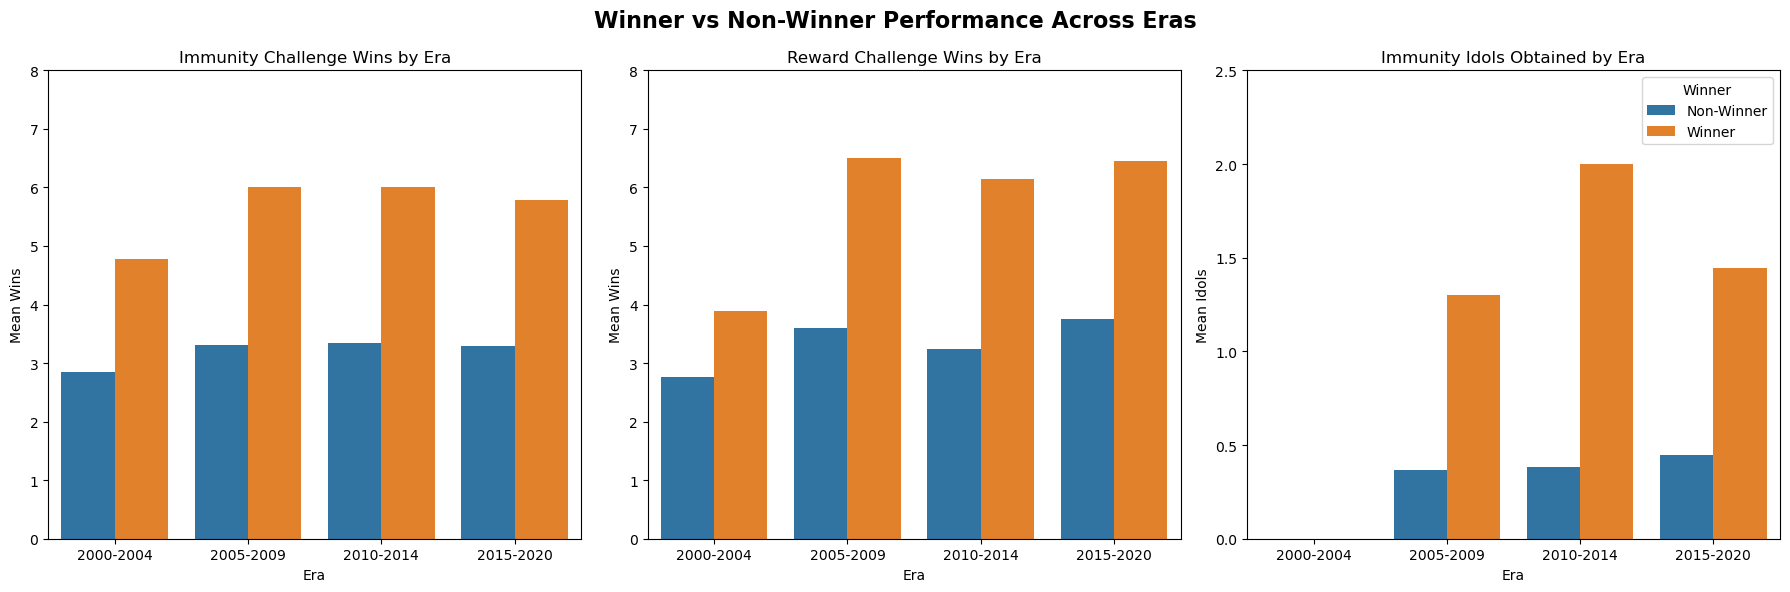

In [56]:
outplay_analysis_df = analysis_df.copy()

#drop seasons with re-entry abilities, skews the data
outplay_analysis_df =outplay_analysis_df[~outplay_analysis_df["season"].isin([22, 23, 27, 38, 40])]

#sort from low to high seasons
outplay_analysis_df = outplay_analysis_df.sort_values(by="season")

#create bins to group seasons into eras of the game
season_bins = [1999, 2004, 2009, 2014, 2020]
season_labels = ["2000-2004", "2005-2009", "2010-2014", "2015-2020"]

#add new column for eras
outplay_analysis_df["era"] = pd.cut(
    outplay_analysis_df["season_year"],
    bins = season_bins,
    labels = season_labels
)

era_means = outplay_analysis_df.groupby(["era", "is_winner"])[["immunity_challenge_wins", "reward_challenge_wins", "immunity_idols_obtained"]].mean()
era_means = era_means.reset_index()

#manually edit immunity_idols for 2000-2004, there were no idols introduced until 2005
era_means.loc[era_means["era"] == "2000-2004", "immunity_idols_obtained"] = 0

#visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(
    data=era_means,
    x="era",
    y="immunity_challenge_wins",
    hue="is_winner",
    ax=axes[0]
)

sns.barplot(
    data=era_means,
    x="era",
    y="reward_challenge_wins",
    hue="is_winner",
    ax=axes[1]
)

sns.barplot(
    data=era_means,
    x="era",
    y="immunity_idols_obtained",
    hue="is_winner",
    ax=axes[2]
)


#formatting
axes[0].set_title("Immunity Challenge Wins by Era")
axes[0].set_xlabel("Era")
axes[0].set_ylabel("Mean Wins")

axes[1].set_title("Reward Challenge Wins by Era")
axes[1].set_xlabel("Era")
axes[1].set_ylabel("Mean Wins")

axes[2].set_title("Immunity Idols Obtained by Era")
axes[2].set_xlabel("Era")
axes[2].set_ylabel("Mean Idols")

#normalize challenge and reward wins to the same y range
axes[0].set_ylim(0, 8)
axes[1].set_ylim(0, 8)
axes[2].set_ylim(0, 2.5)

#remove redundant labels
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].legend(title="Winner", labels=["Non-Winner", "Winner"], handles=axes[2].legend_.legend_handles)

#final formatting
fig.suptitle("Winner vs Non-Winner Performance Across Eras", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


*Footnote: Immunity idols were not introduced into survivor unti Season 11 in 2005, but the dataframe has values for idols in the 2000-2004 era. This may be representing other advantages, but for our purposes I manually zero-ed out this era to avoid confusion.*

## Observations

The purpose of this visualization was to compare what winners versus losers of Survivor looked like over the different eras of survivor. We were expecting to see challenge and reward wins to decrease over the eras as strategy became more complicated and intense, and players seemed more focused on eliminating strong competitors earlier. 

Surprisingly, based on the graphs we can see that winners have dominated immunity challenges around 2x more, and reward challenges around 2.3x more. This directly challenges the expectation that "challenge-beasts" don't win Survivor. The only exception is the pre-idol era (2000-2004), where the gap between losers and winners is smaller. 

When idols were introduced, it seems like winners had the protection of idols to play more dominantly in challenges without the fear of being voted off. Additonally, players who had both idols and were winning immunity got harder and harder to vote out. This not only proves the outplay component, but also the outlast and outwit. Based on the graph, winners find around 3x more idols than losers. To find idols you have to outwit opponents by understanding where clues may be hidden, and then figuring out how to go look for an idol without your teammates catching on. Additionally, the added protection of an idol allows a player to outlast even when being voted off. 

It should be acknowleged that the winner sample is much smaller per era (8-10 winners versus 125-171 losers), which could skew data. Within the losers sample are contestants who only lasted a few days versus contestants who lasted until the end. 

# Visual 2: Personality Type (MBTI) & Winners
- How dow the MBTI codes correlate with winners?

# Strategy
1. Drop unkowns
2. Split personality MBTI code into 4 boolean letter codes
3. Normalize columns that naturally grow with time

In [57]:
# Create a copy for the MBTI correlation heatmap
mbti_heatmap_df = analysis_df.copy()

# Rename idol column if the notebook used a different final name
if "immunity_idols_obtained" not in mbti_heatmap_df.columns:
    if "immunity_idols_found" in mbti_heatmap_df.columns:
        mbti_heatmap_df = mbti_heatmap_df.rename(
            columns={"immunity_idols_found": "immunity_idols_obtained"}
        )

# Keep only rows with a real MBTI type
mbti_heatmap_df = mbti_heatmap_df[
    mbti_heatmap_df["personality_type"] != "UNKNOWN"
].copy()

# Create MBTI letter flags
# These use one side of each MBTI pair to avoid duplicate opposite columns
mbti_heatmap_df["is_extrovert"] = (
    mbti_heatmap_df["personality_type"].str[0] == "E"
).astype(int)

mbti_heatmap_df["is_intuitive"] = (
    mbti_heatmap_df["personality_type"].str[1] == "N"
).astype(int)

mbti_heatmap_df["is_thinking"] = (
    mbti_heatmap_df["personality_type"].str[2] == "T"
).astype(int)

mbti_heatmap_df["is_judging"] = (
    mbti_heatmap_df["personality_type"].str[3] == "J"
).astype(int)

# Convert winner label to 0/1 for correlation
mbti_heatmap_df["winner_flag"] = mbti_heatmap_df["is_winner"].astype(int)

# Normalize metrics that naturally grow with time in the game
mbti_heatmap_df["survival_pct"] = (
    mbti_heatmap_df["order"] /
    mbti_heatmap_df.groupby("season")["order"].transform("max")
)

mbti_heatmap_df["votes_per_day"] = (
    mbti_heatmap_df["total_votes_received"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["idols_per_day"] = (
    mbti_heatmap_df["immunity_idols_obtained"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["immunity_wins_per_day"] = (
    mbti_heatmap_df["immunity_challenge_wins"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["reward_wins_per_day"] = (
    mbti_heatmap_df["reward_challenge_wins"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

# Select MBTI dimensions and outcome/gameplay metrics
mbti_columns = [
    "is_extrovert",
    "is_intuitive",
    "is_thinking",
    "is_judging"
]

metric_columns = [
    "winner_flag",
    "survival_pct",
    "votes_per_day",
    "idols_per_day",
    "immunity_wins_per_day",
    "reward_wins_per_day"
]

# Create a focused correlation table
mbti_correlation_matrix = mbti_heatmap_df[
    mbti_columns + metric_columns
].corr()

mbti_correlation_focus = mbti_correlation_matrix.loc[
    mbti_columns,
    metric_columns
].round(2)

mbti_correlation_focus

,winner_flag,survival_pct,votes_per_day,idols_per_day,immunity_wins_per_day,reward_wins_per_day
is_extrovert,0.03,0.01,-0.03,0.02,0.04,0.01
is_intuitive,0.01,0.04,0.02,-0.05,0.01,0.04
is_thinking,0.06,-0.00,0.01,0.10,0.05,-0.02
is_judging,-0.00,0.01,-0.01,-0.02,-0.05,-0.06


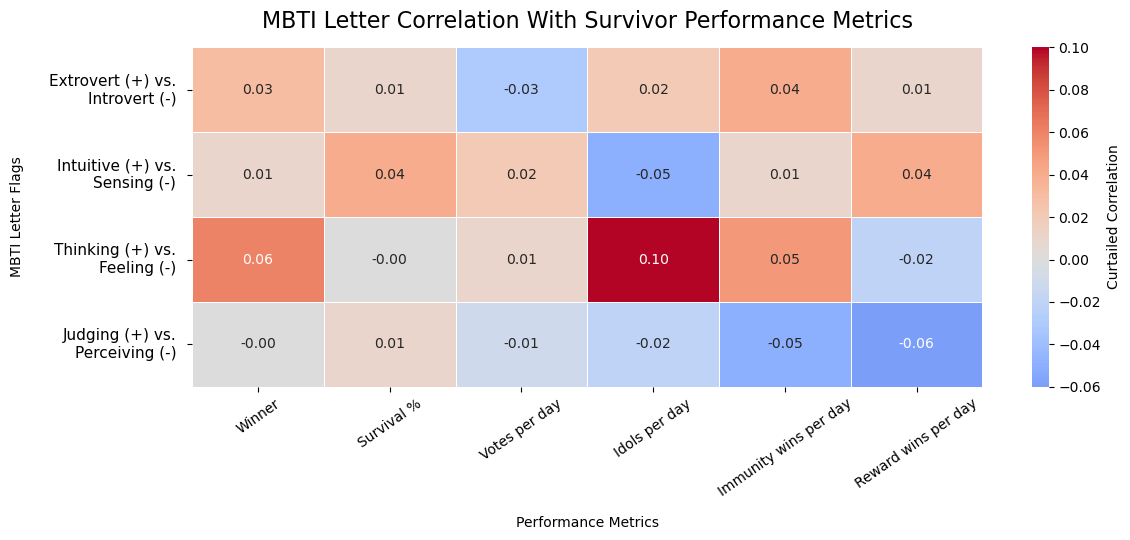

In [58]:
mbti_correlation_plot = mbti_correlation_focus.rename(
    index={
        "is_extrovert": f"Extrovert (+) vs.\nIntrovert (-)",
        "is_intuitive": f"Intuitive (+) vs.\nSensing (-)",
        "is_thinking": f"Thinking (+) vs.\nFeeling (-)",
        "is_judging": f"Judging (+) vs.\nPerceiving (-)"
    },
    columns={
        "winner_flag": "Winner",
        "survival_pct": "Survival %",
        "votes_per_day": "Votes per day",
        "idols_per_day": "Idols per day",
        "immunity_wins_per_day": "Immunity wins per day",
        "reward_wins_per_day": "Reward wins per day"
    }
)

# Draw Heat Map
fig, ax = plt.subplots(figsize=(12, 5.5))

sns.heatmap(
    data=mbti_correlation_plot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Curtailed Correlation"}
)

ax.set_title(
    "MBTI Letter Correlation With Survivor Performance Metrics",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Performance Metrics", labelpad=12)
ax.set_ylabel("MBTI Letter Flags", labelpad=18)

ax.tick_params(axis="x", labelrotation=35, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=11, pad=8)

plt.tight_layout()
plt.show()

### MBTI Correlation Heatmap Observation

This heatmap compares MBTI letter dimensions against winner status and normalized Survivor performance metrics. I split each personality type into broader letter flags because the full four-letter MBTI groups are small, while the Extrovert/Introvert (E/I), Sensing/Intuitive (S/N), Thinking/Feeling (T/F), and Judging/Perceiving (J/P) dimensions give a cleaner view of the data.

The correlations are mostly weak, which means MBTI alone does not strongly explain who wins or performs well. Still, a few small patterns are worth noticing. Thinking types show the strongest positive relationship with winner status and idols per day, while judging types trend slightly lower across challenge-win metrics. These are not definitive conclusions, but they give us a useful starting point for asking better questions.

I also normalized votes, idols, and challenge wins by days survived because raw totals naturally favor players who lasted longer. That keeps the visual more objectively correct. Instead of treating personality as the be all and end all, this heatmap treats it as one measure among many being that of a small signal inside the much bigger social game.

In [59]:
print("MBTI heatmap rows:", len(mbti_heatmap_df))
print("\nColumns used:")
print(mbti_columns + metric_columns)

print("\nMissing values:")
print(mbti_heatmap_df[mbti_columns + metric_columns].isna().sum())

MBTI heatmap rows: 738

Columns used:
['is_extrovert', 'is_intuitive', 'is_thinking', 'is_judging', 'winner_flag', 'survival_pct', 'votes_per_day', 'idols_per_day', 'immunity_wins_per_day', 'reward_wins_per_day']

Missing values:
is_extrovert             0
is_intuitive             0
is_thinking              0
is_judging               0
winner_flag              0
survival_pct             0
votes_per_day            0
idols_per_day            0
immunity_wins_per_day    0
reward_wins_per_day      0
dtype: int64


# Visual 3: Winners & Votes
- How are winners receiving votes compared to non-winners?

## Strategy
1. Normalize total votes received according to time
2. Use a violin chart to illustrate

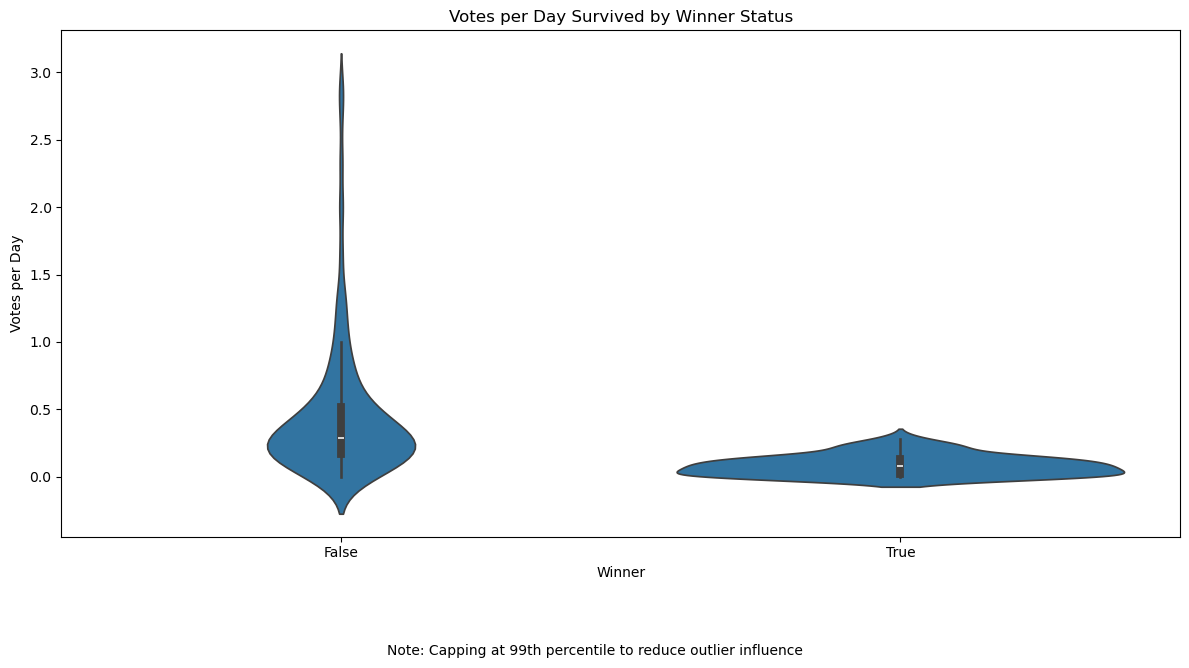

In [60]:
#Create a copy of the analysis dataframe
votes_outcome_df = analysis_df.copy()

# Normalize votes by days survived
votes_outcome_df["votes_per_day"] = (
    votes_outcome_df["total_votes_received"] /
    votes_outcome_df["day"].clip(lower=1)
)

vote_cap = votes_outcome_df["votes_per_day"].quantile(0.99)
votes_outcome_df["vote_plot"] = votes_outcome_df["votes_per_day"].clip(upper=vote_cap)

# Violin plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    x="is_winner",
    y="vote_plot",
    ax=ax,
    inner="box",
    data=votes_outcome_df,
)

# Formatting
ax.set_title("Votes per Day Survived by Winner Status")
ax.set_xlabel("Winner")
ax.set_ylabel("Votes per Day")
fig.text(0.5, -0.1, "Note: Capping at 99th percentile to reduce outlier influence", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## Observation

### Notes
From the early global statistics, the non-winners have a approximately double the median and mean votes received than winners. The violin chart above accounts for votes received per day, to focus in on the rate of accumulation rather than total votes received. 

Limitations: The non-winner group mixes in people who were voted off early, so the votes recieved per day has big swings, and a few people collect many of votes. The length of its violin partly reflects game length and how often someone is targeted.

### Thoughts
It appears that the majority of winners receive a very low number of votes per day, whereas non-winners have a wider distribution of votes at a higher rate per day then winners.

# Simeon's Question
**Fill Below**

# Emma's Question
**Fill Below**

# Jarren's Question
## MBTI Question Answering and Conclusion

For Phase 3, I am narrowing my analysis to the MBTI patterns that came out of my Phase 2 heatmap work. The heatmap showed mostly weak correlations between MBTI letter flags and Survivor performance metrics, so my next step is not to claim that personality predicts winning. The better question is whether personality becomes more meaningful when we look at representation, rarity, era, and tenure.

These questions are intentionally very simple, but they still go beyond just looking at the data:

1. Are there MBTI types that are underrepresented, but win more often than others?
2. Are rare MBTI types different from common MBTI types in winner rate and survival depth?
3. Which eras do different MBTI types win more often in?
4. Do certain MBTI types last longer than others?

The goal is to treat MBTI as a thought experiment, not an end all be all. Survivor is still a social game built on timing, relationships, advantages, and perception.

In [61]:
# Phase 3 setup for MBTI question answering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Work from the merged analysis dataframe
phase3_df = analysis_df.copy()


# Helper function to safely choose a column from possible names
def choose_column(df, possible_names, friendly_name):
    for name in possible_names:
        if name in df.columns:
            return name

    raise KeyError(
        f"Could not find a column for {friendly_name}. "
        f"Checked these names: {possible_names}"
    )


name_col = choose_column(
    phase3_df,
    ["full_name", "castaway", "castaway_name"],
    "contestant name"
)

mbti_col = choose_column(
    phase3_df,
    ["personality_type", "mbti", "MBTI"],
    "MBTI personality type"
)

winner_col = choose_column(
    phase3_df,
    ["is_winner", "winner"],
    "winner label"
)

season_col = choose_column(
    phase3_df,
    ["season"],
    "season"
)

season_year_col = choose_column(
    phase3_df,
    ["season_year", "year"],
    "season year"
)

order_col = choose_column(
    phase3_df,
    ["order", "placement"],
    "finish order"
)

day_col = choose_column(
    phase3_df,
    ["day", "days"],
    "days lasted"
)

votes_col = choose_column(
    phase3_df,
    ["total_votes_received", "votes_received"],
    "total votes received"
)

idols_col = choose_column(
    phase3_df,
    ["immunity_idols_found", "immunity_idols_obtained"],
    "immunity idols"
)

immunity_wins_col = choose_column(
    phase3_df,
    ["immunity_challenge_wins"],
    "immunity challenge wins"
)

reward_wins_col = choose_column(
    phase3_df,
    ["reward_challenge_wins"],
    "reward challenge wins"
)


# Standardize the columns used in this section
phase3_df["player_name"] = phase3_df[name_col]
phase3_df["personality_type_clean"] = (
    phase3_df[mbti_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

phase3_df["is_winner_bool"] = phase3_df[winner_col].astype(bool)
phase3_df["season_num"] = phase3_df[season_col]
phase3_df["season_year_clean"] = phase3_df[season_year_col]
phase3_df["finish_order"] = phase3_df[order_col]
phase3_df["days_lasted"] = phase3_df[day_col]
phase3_df["votes_received"] = phase3_df[votes_col]
phase3_df["idols_found"] = phase3_df[idols_col]
phase3_df["immunity_wins"] = phase3_df[immunity_wins_col]
phase3_df["reward_wins"] = phase3_df[reward_wins_col]

# Keep only real four-letter MBTI types
valid_mbti_mask = phase3_df["personality_type_clean"].str.match(
    r"^[EI][SN][TF][JP]$",
    na=False
)

mbti_phase3_df = phase3_df.loc[valid_mbti_mask].copy()

# Normalize depth so seasons with different cast sizes can be compared
mbti_phase3_df["season_max_order"] = (
    mbti_phase3_df.groupby("season_num")["finish_order"].transform("max")
)

mbti_phase3_df["survival_pct"] = (
    mbti_phase3_df["finish_order"] /
    mbti_phase3_df["season_max_order"]
)

# Per-day metrics keep tenure from dominating every comparison
mbti_phase3_df["day_safe"] = mbti_phase3_df["days_lasted"].clip(lower=1)
mbti_phase3_df["votes_per_day"] = (
    mbti_phase3_df["votes_received"] / mbti_phase3_df["day_safe"]
)
mbti_phase3_df["idols_per_day"] = (
    mbti_phase3_df["idols_found"] / mbti_phase3_df["day_safe"]
)
mbti_phase3_df["immunity_wins_per_day"] = (
    mbti_phase3_df["immunity_wins"] / mbti_phase3_df["day_safe"]
)
mbti_phase3_df["reward_wins_per_day"] = (
    mbti_phase3_df["reward_wins"] / mbti_phase3_df["day_safe"]
)

# Era bins based on the project discussion
mbti_phase3_df["era"] = pd.cut(
    mbti_phase3_df["season_year_clean"],
    bins=[1999, 2004, 2009, 2014, 2020],
    labels=["2000-2004", "2005-2009", "2010-2014", "2015-2020"],
    include_lowest=True
)

# MBTI letter dimensions
mbti_phase3_df["E_or_I"] = mbti_phase3_df["personality_type_clean"].str[0]
mbti_phase3_df["S_or_N"] = mbti_phase3_df["personality_type_clean"].str[1]
mbti_phase3_df["T_or_F"] = mbti_phase3_df["personality_type_clean"].str[2]
mbti_phase3_df["J_or_P"] = mbti_phase3_df["personality_type_clean"].str[3]

print("Rows in analysis_df:", len(analysis_df))
print("Rows with valid MBTI:", len(mbti_phase3_df))
print("MBTI types found:", mbti_phase3_df["personality_type_clean"].nunique())

display(
    mbti_phase3_df[
        [
            "player_name",
            "personality_type_clean",
            "is_winner_bool",
            "season_num",
            "season_year_clean",
            "era",
            "finish_order",
            "days_lasted",
            "survival_pct"
        ]
    ].head()
)

Rows in analysis_df: 741
Rows with valid MBTI: 738
MBTI types found: 16


,player_name,personality_type_clean,is_winner_bool,season_num,season_year_clean,era,finish_order,days_lasted,survival_pct
0,Natalie Anderson,ESTP,False,40,2020,2015-2020,1,2,0.045455
1,Amber Mariano,ISFP,False,40,2020,2015-2020,2,3,0.090909
2,Danni Boatwright,ENFJ,False,40,2020,2015-2020,3,6,0.136364
3,Ethan Zohn,ISFP,False,40,2020,2015-2020,4,9,0.181818
4,Tyson Apostol,ESTP,False,40,2020,2015-2020,5,11,0.227273


## Question 1: Are there MBTI types that are underrepresented, but win more often than others?

My Phase 2 heatmap suggested that MBTI does not have a strong direct correlation with winning. However, full MBTI types are small groups. A type can be rare in the cast, but still have a higher winner rate than expected. This question checks whether any underrepresented personality types stand out after accounting for how many players of each type appear in the dataset.

,mbti_type,players,winners,median_survival_pct,median_days_lasted,median_votes_per_day,median_immunity_wins_per_day,winner_rate,representation_share,representation_group,above_overall_winner_rate
8,INFJ,26,4,0.58,27.0,0.297,0.095,0.154,0.035,Underrepresented,True
7,ESTP,63,8,0.55,25.0,0.259,0.133,0.127,0.085,More common,True
3,ENTP,46,5,0.50,24.0,0.325,0.132,0.109,0.062,More common,True
0,ENFJ,38,3,0.74,34.0,0.195,0.128,0.079,0.051,Underrepresented,True
10,INTJ,26,2,0.55,27.0,0.252,0.155,0.077,0.035,Underrepresented,True
15,ISTP,33,2,0.61,27.0,0.214,0.148,0.061,0.045,Underrepresented,True
6,ESTJ,53,3,0.45,21.0,0.278,0.133,0.057,0.072,More common,True
11,INTP,41,2,0.60,30.0,0.273,0.152,0.049,0.056,Underrepresented,False
5,ESFP,67,3,0.56,27.0,0.273,0.139,0.045,0.091,More common,False
2,ENTJ,30,1,0.56,27.0,0.251,0.150,0.033,0.041,Underrepresented,False


Overall MBTI-known winner rate: 0.054
Median MBTI type count: 43.5


,mbti_type,players,winners,median_survival_pct,median_days_lasted,median_votes_per_day,median_immunity_wins_per_day,winner_rate,representation_share,representation_group,above_overall_winner_rate
8,INFJ,26,4,0.58,27.0,0.297,0.095,0.154,0.035,Underrepresented,True
0,ENFJ,38,3,0.74,34.0,0.195,0.128,0.079,0.051,Underrepresented,True
10,INTJ,26,2,0.55,27.0,0.252,0.155,0.077,0.035,Underrepresented,True
15,ISTP,33,2,0.61,27.0,0.214,0.148,0.061,0.045,Underrepresented,True


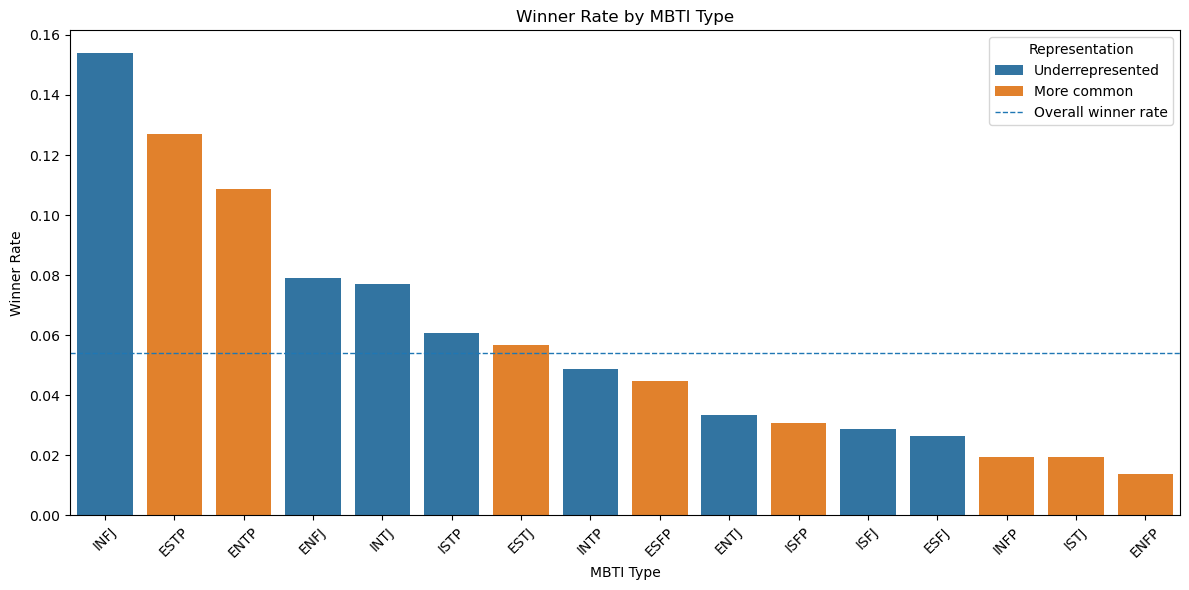

**Answer:** The strongest underrepresented type by winner rate is **INFJ**, with **4 winners out of 26 players**. Its winner rate is **0.154**, compared with the overall MBTI-known winner rate of **0.054**. This is interesting, but it should be read carefully because rare types can swing heavily when one person wins.

In [62]:
# Question 1: Underrepresented MBTI types and winner rate

mbti_type_summary = (
    mbti_phase3_df
    .groupby("personality_type_clean", observed=True)
    .agg(
        players=("player_name", "count"),
        winners=("is_winner_bool", "sum"),
        median_survival_pct=("survival_pct", "median"),
        median_days_lasted=("days_lasted", "median"),
        median_votes_per_day=("votes_per_day", "median"),
        median_immunity_wins_per_day=("immunity_wins_per_day", "median")
    )
    .reset_index()
    .rename(columns={"personality_type_clean": "mbti_type"})
)

mbti_type_summary["winner_rate"] = (
    mbti_type_summary["winners"] / mbti_type_summary["players"]
)

mbti_type_summary["representation_share"] = (
    mbti_type_summary["players"] / mbti_type_summary["players"].sum()
)

# Below-median player count means underrepresented for this dataset
type_count_median = mbti_type_summary["players"].median()
overall_winner_rate = (
    mbti_type_summary["winners"].sum() / mbti_type_summary["players"].sum()
)

mbti_type_summary["representation_group"] = np.where(
    mbti_type_summary["players"] < type_count_median,
    "Underrepresented",
    "More common"
)

mbti_type_summary["above_overall_winner_rate"] = (
    mbti_type_summary["winner_rate"] > overall_winner_rate
)

underrepresented_winners = (
    mbti_type_summary[
        (mbti_type_summary["representation_group"] == "Underrepresented") &
        (mbti_type_summary["above_overall_winner_rate"])
    ]
    .sort_values(["winner_rate", "players"], ascending=[False, False])
)

display(
    mbti_type_summary
    .sort_values(["winner_rate", "players"], ascending=[False, False])
    .style.format(
        {
            "winner_rate": "{:.3f}",
            "representation_share": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "median_days_lasted": "{:.1f}",
            "median_votes_per_day": "{:.3f}",
            "median_immunity_wins_per_day": "{:.3f}"
        }
    )
)

print("Overall MBTI-known winner rate:", round(overall_winner_rate, 3))
print("Median MBTI type count:", type_count_median)

display(
    underrepresented_winners.style.format(
        {
            "winner_rate": "{:.3f}",
            "representation_share": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "median_days_lasted": "{:.1f}",
            "median_votes_per_day": "{:.3f}",
            "median_immunity_wins_per_day": "{:.3f}"
        }
    )
)

# Visual: winner rate by MBTI type
plot_df = mbti_type_summary.sort_values("winner_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="mbti_type",
    y="winner_rate",
    hue="representation_group",
    errorbar=None,
    ax=ax
)

ax.axhline(
    overall_winner_rate,
    linestyle="--",
    linewidth=1,
    label="Overall winner rate"
)

ax.set_title("Winner Rate by MBTI Type")
ax.set_xlabel("MBTI Type")
ax.set_ylabel("Winner Rate")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Representation")

plt.tight_layout()
plt.show()

# Text
if len(underrepresented_winners) > 0:
    top_underrepresented = underrepresented_winners.iloc[0]

    display(Markdown(
        f"**Answer:** The strongest underrepresented type by winner rate is "
        f"**{top_underrepresented['mbti_type']}**, with "
        f"**{top_underrepresented['winners']} winners out of "
        f"{top_underrepresented['players']} players**. Its winner rate is "
        f"**{top_underrepresented['winner_rate']:.3f}**, compared with the "
        f"overall MBTI-known winner rate of **{overall_winner_rate:.3f}**. "
        f"This is interesting, but it should be read carefully because rare "
        f"types can swing heavily when one person wins."
    ))
else:
    display(Markdown(
        "**Answer:** No underrepresented MBTI type clearly rises above the "
        "overall winner rate in this version of the cleaned data. That supports "
        "the earlier heatmap result: MBTI may be interesting, but it is not a "
        "strong standalone explanation for winning."
    ))

## Question 2: Are rare MBTI types different from common MBTI types?
The first question looks at individual MBTI types, but those groups can be tiny. This question zooms out and compares rare types against common types as groups. That makes the analysis more stable and helps test whether rarity itself is connected to winning, tenure, or vote exposure.

,representation_group,players,winners,mbti_types,median_survival_pct,median_days_lasted,median_votes_per_day,median_idols_per_day,median_immunity_wins_per_day,median_reward_wins_per_day,winner_rate
0,More common,471,24,8,0.50,24.0,0.292,0.000,0.132,0.138,0.051
1,Underrepresented,267,16,8,0.60,28.0,0.258,0.000,0.132,0.139,0.060


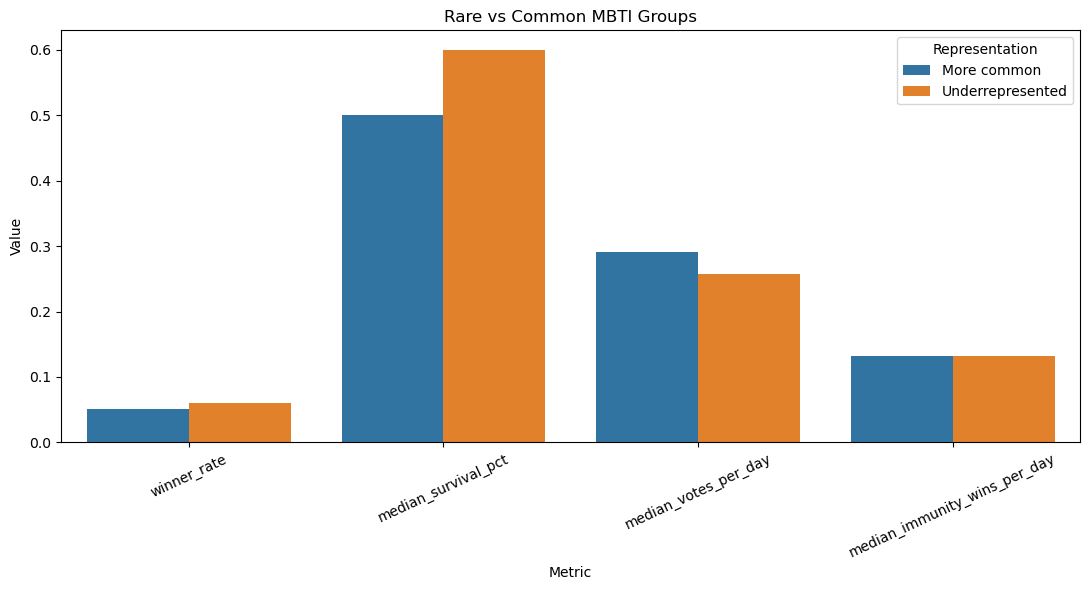

**Answer:** The **Underrepresented** group has the higher winner rate in this comparison at **0.060**, compared with **0.051** for the **More common** group. The important caveat is that this does not prove rare personalities are better at Survivor. It only shows that representation and winner rate are worth separating instead of treating all MBTI types as equally sized groups.

In [63]:
# Question 2: Rare vs common MBTI types

rare_common_lookup = mbti_type_summary[
    ["mbti_type", "representation_group"]
].copy()

rare_common_df = mbti_phase3_df.merge(
    rare_common_lookup,
    left_on="personality_type_clean",
    right_on="mbti_type",
    how="left"
)

rare_common_summary = (
    rare_common_df
    .groupby("representation_group", observed=True)
    .agg(
        players=("player_name", "count"),
        winners=("is_winner_bool", "sum"),
        mbti_types=("personality_type_clean", "nunique"),
        median_survival_pct=("survival_pct", "median"),
        median_days_lasted=("days_lasted", "median"),
        median_votes_per_day=("votes_per_day", "median"),
        median_idols_per_day=("idols_per_day", "median"),
        median_immunity_wins_per_day=("immunity_wins_per_day", "median"),
        median_reward_wins_per_day=("reward_wins_per_day", "median")
    )
    .reset_index()
)

rare_common_summary["winner_rate"] = (
    rare_common_summary["winners"] / rare_common_summary["players"]
)

display(
    rare_common_summary.style.format(
        {
            "winner_rate": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "median_days_lasted": "{:.1f}",
            "median_votes_per_day": "{:.3f}",
            "median_idols_per_day": "{:.3f}",
            "median_immunity_wins_per_day": "{:.3f}",
            "median_reward_wins_per_day": "{:.3f}"
        }
    )
)

# Visual: rare vs common comparison
rare_common_plot_df = rare_common_summary.melt(
    id_vars="representation_group",
    value_vars=[
        "winner_rate",
        "median_survival_pct",
        "median_votes_per_day",
        "median_immunity_wins_per_day"
    ],
    var_name="metric",
    value_name="value"
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=rare_common_plot_df,
    x="metric",
    y="value",
    hue="representation_group",
    errorbar=None,
    ax=ax
)

ax.set_title("Rare vs Common MBTI Groups")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Representation")

plt.tight_layout()
plt.show()

# Text
rare_common_sorted = rare_common_summary.sort_values(
    "winner_rate",
    ascending=False
)

top_group = rare_common_sorted.iloc[0]
bottom_group = rare_common_sorted.iloc[-1]

display(Markdown(
    f"**Answer:** The **{top_group['representation_group']}** group has the "
    f"higher winner rate in this comparison at **{top_group['winner_rate']:.3f}**, "
    f"compared with **{bottom_group['winner_rate']:.3f}** for the "
    f"**{bottom_group['representation_group']}** group. The important caveat is "
    f"that this does not prove rare personalities are better at Survivor. It only "
    f"shows that representation and winner rate are worth separating instead of "
    f"treating all MBTI types as equally sized groups."
))

## Question 3: Which eras do different MBTI types win more often in?

Survivor changes over time. Strategy, idols, casting, tribe swaps, and endgame expectations are not the same across every era. If MBTI has any useful signal, it may show up differently by era instead of appearing as one simple all-time pattern.

,era,mbti_type,players,winners,median_survival_pct,median_votes_per_day,winner_rate
15,2000-2004,ISTP,7,2,0.83,0.162,0.286
3,2000-2004,ENTP,8,2,0.81,0.189,0.250
13,2000-2004,ISFP,12,2,0.32,0.393,0.167
4,2000-2004,ESFJ,12,1,0.58,0.202,0.083
7,2000-2004,ESTP,13,1,0.62,0.200,0.077
14,2000-2004,ISTJ,19,1,0.50,0.333,0.053
1,2000-2004,ENFP,14,0,0.41,0.400,0.000
6,2000-2004,ESTJ,13,0,0.44,0.286,0.000
5,2000-2004,ESFP,12,0,0.44,0.285,0.000
9,2000-2004,INFP,10,0,0.69,0.234,0.000


mbti_type,ENFJ,ENFP,ENTJ,ENTP,ESFJ,ESFP,ESTJ,ESTP,INFJ,INFP,INTJ,INTP,ISFJ,ISFP,ISTJ,ISTP
era,,,,,,,,,,,,,,,,
2000-2004,0,0,0,2,1,0,0,1,0,0,0,0,0,2,1,2
2005-2009,2,1,0,0,0,0,1,1,1,1,1,1,1,0,0,0
2010-2014,0,0,0,0,0,1,1,4,2,0,1,1,0,0,0,0
2015-2020,1,0,1,3,0,2,1,2,1,0,0,0,0,0,0,0


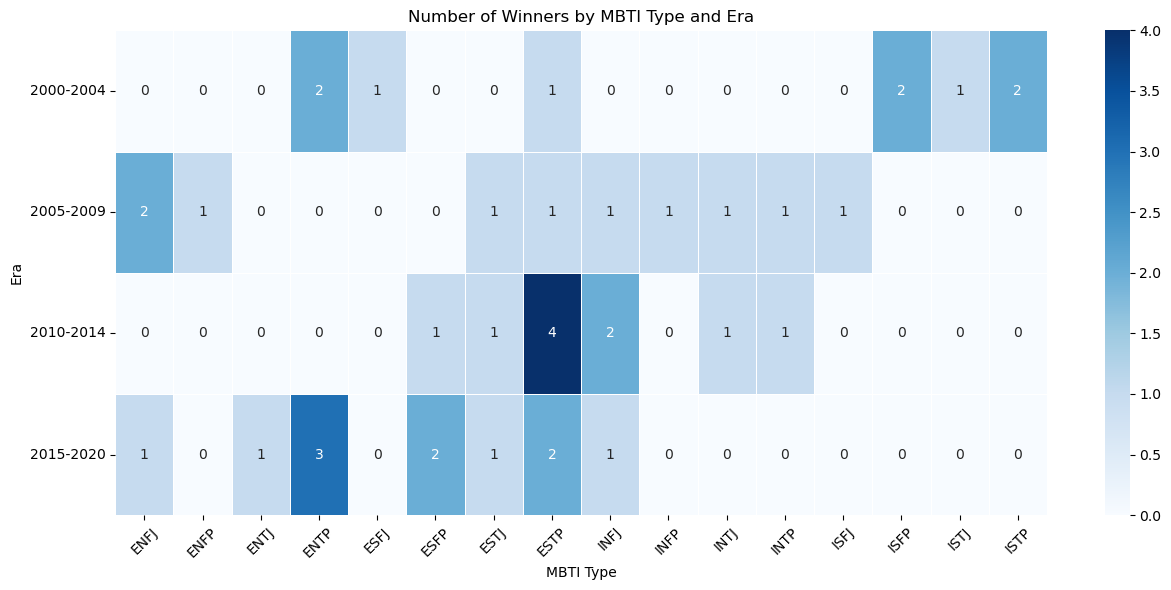

,era,mbti_type,players,winners,winner_rate,median_survival_pct
0,2000-2004,ISTP,7,2,0.286,0.83
1,2005-2009,ENFJ,11,2,0.182,0.75
2,2010-2014,ESTP,17,4,0.235,0.60
3,2015-2020,ENTP,19,3,0.158,0.55


**Answer:** The winning MBTI pattern changes by era rather than forming one clean all-time personality trend.

- In **2000-2004**, the leading winner-count MBTI type is **ISTP** with **2 winners** out of **7 players**.
- In **2005-2009**, the leading winner-count MBTI type is **ENFJ** with **2 winners** out of **11 players**.
- In **2010-2014**, the leading winner-count MBTI type is **ESTP** with **4 winners** out of **17 players**.
- In **2015-2020**, the leading winner-count MBTI type is **ENTP** with **3 winners** out of **19 players**.

In [64]:
# Question 3: MBTI winner patterns by era

era_type_summary = (
    mbti_phase3_df
    .dropna(subset=["era"])
    .groupby(["era", "personality_type_clean"], observed=True)
    .agg(
        players=("player_name", "count"),
        winners=("is_winner_bool", "sum"),
        median_survival_pct=("survival_pct", "median"),
        median_votes_per_day=("votes_per_day", "median")
    )
    .reset_index()
    .rename(columns={"personality_type_clean": "mbti_type"})
)

era_type_summary["winner_rate"] = (
    era_type_summary["winners"] / era_type_summary["players"]
)

display(
    era_type_summary
    .sort_values(["era", "winner_rate", "players"], ascending=[True, False, False])
    .style.format(
        {
            "winner_rate": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "median_votes_per_day": "{:.3f}"
        }
    )
)

# Winner counts by era and type are more stable than rates for tiny groups
era_winner_counts = (
    era_type_summary
    .pivot_table(
        index="era",
        columns="mbti_type",
        values="winners",
        aggfunc="sum",
        fill_value=0,
        observed=True
    )
)

display(era_winner_counts)

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    era_winner_counts,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Number of Winners by MBTI Type and Era")
ax.set_xlabel("MBTI Type")
ax.set_ylabel("Era")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Best type per era by winner count, using winner rate as a tie-breaker
best_era_types = (
    era_type_summary
    .sort_values(
        ["era", "winners", "winner_rate", "players"],
        ascending=[True, False, False, False]
    )
    .groupby("era", observed=True)
    .head(1)
    .reset_index(drop=True)
)

display(
    best_era_types[
        [
            "era",
            "mbti_type",
            "players",
            "winners",
            "winner_rate",
            "median_survival_pct"
        ]
    ].style.format(
        {
            "winner_rate": "{:.3f}",
            "median_survival_pct": "{:.2f}"
        }
    )
)

era_sentences = []

for _, row in best_era_types.iterrows():
    era_sentences.append(
        f"- In **{row['era']}**, the leading winner-count MBTI type is "
        f"**{row['mbti_type']}** with **{int(row['winners'])} winners** "
        f"out of **{int(row['players'])} players**."
    )

display(Markdown(
    "**Answer:** The winning MBTI pattern changes by era rather than forming "
    "one clean all-time personality trend.\n\n" + "\n".join(era_sentences)
))

## Question 4: Do certain MBTI types have longer tenure than others?

Winning is rare, so winner rate alone can be noisy. Tenure gives a broader view of performance because it asks who tends to last longer, not only who wins. This question checks whether MBTI types or MBTI letter dimensions show meaningful differences in survival depth.

,mbti_type,players,winners,median_survival_pct,mean_survival_pct,median_days_lasted,mean_days_lasted,median_finish_order,median_votes_per_day,winner_rate
0,ENFJ,38,3,0.74,0.65,34.0,29.3,13.0,0.195,0.079
15,ISTP,33,2,0.61,0.60,27.0,26.5,11.0,0.214,0.061
11,INTP,41,2,0.60,0.57,30.0,26.0,12.0,0.273,0.049
8,INFJ,26,4,0.58,0.56,27.0,24.7,12.0,0.297,0.154
5,ESFP,67,3,0.56,0.55,27.0,25.1,11.0,0.273,0.045
2,ENTJ,30,1,0.56,0.59,27.0,26.8,10.5,0.251,0.033
10,INTJ,26,2,0.55,0.54,27.0,24.8,11.0,0.252,0.077
7,ESTP,63,8,0.55,0.51,25.0,22.6,9.0,0.259,0.127
13,ISFP,65,2,0.50,0.52,24.0,23.8,9.0,0.267,0.031
12,ISFJ,35,1,0.50,0.52,24.0,23.3,10.0,0.300,0.029


,dimension,letter,players,winners,winner_rate,median_survival_pct,median_days_lasted,median_votes_per_day
0,E/I,E,408,25,0.061,0.55,25.5,0.270
1,E/I,I,330,15,0.045,0.50,24.0,0.286
2,S/N,N,332,19,0.057,0.55,26.0,0.294
3,S/N,S,406,21,0.052,0.50,24.0,0.267
4,T/F,F,394,16,0.041,0.55,25.0,0.284
5,T/F,T,344,24,0.070,0.52,24.0,0.267
6,J/P,J,298,16,0.054,0.55,24.5,0.267
7,J/P,P,440,24,0.055,0.52,24.5,0.282


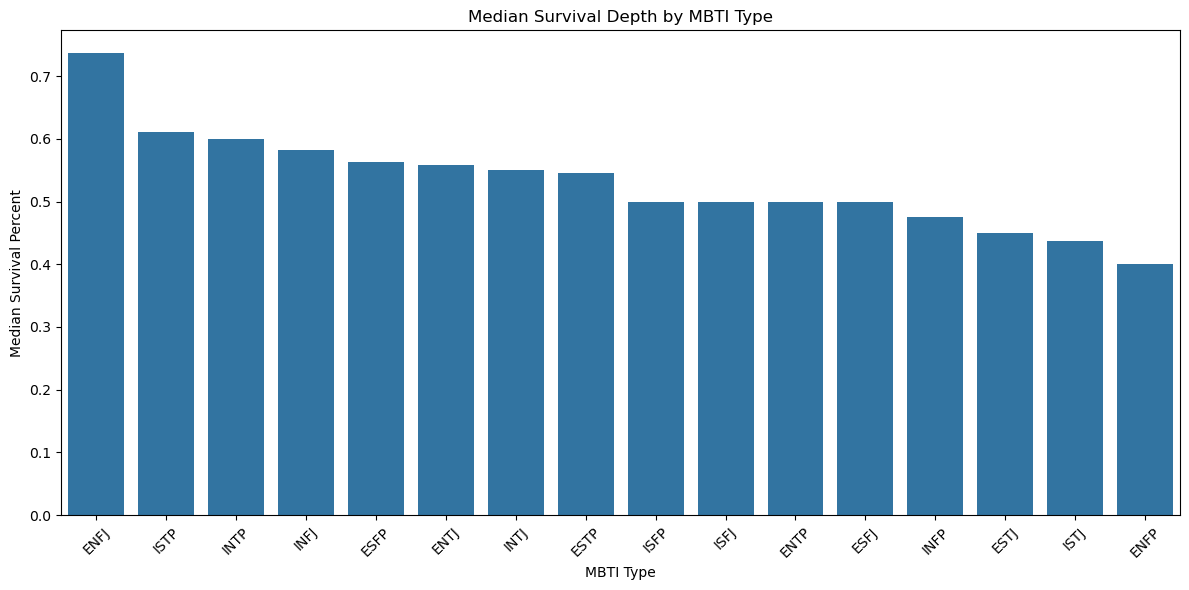

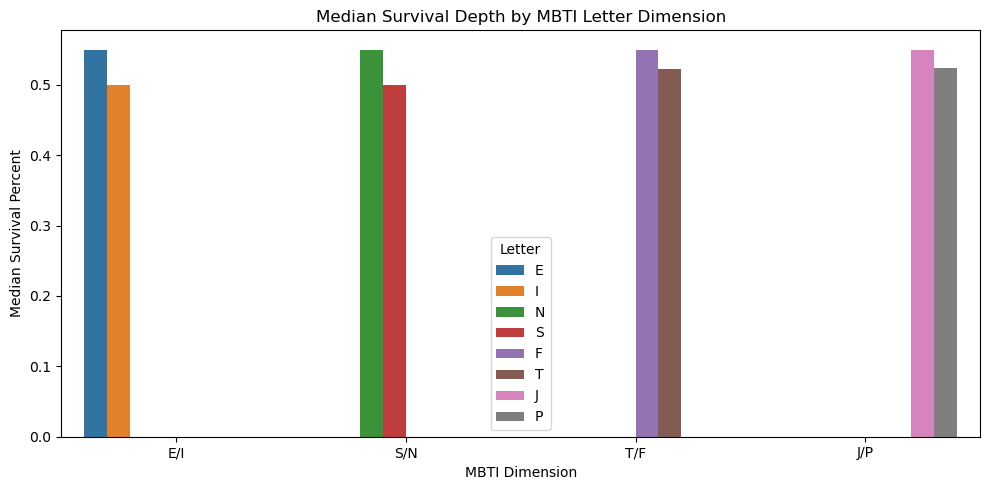

**Answer:** The MBTI type with the highest median survival depth is **ENFJ**, with a median survival percent of **0.74** across **38 players**. This is a better signal than winner rate alone because it looks at how long players stay in the game, not only whether they reach the final outcome.

In [65]:
# Question 4: MBTI and tenure

mbti_tenure_summary = (
    mbti_phase3_df
    .groupby("personality_type_clean", observed=True)
    .agg(
        players=("player_name", "count"),
        winners=("is_winner_bool", "sum"),
        median_survival_pct=("survival_pct", "median"),
        mean_survival_pct=("survival_pct", "mean"),
        median_days_lasted=("days_lasted", "median"),
        mean_days_lasted=("days_lasted", "mean"),
        median_finish_order=("finish_order", "median"),
        median_votes_per_day=("votes_per_day", "median")
    )
    .reset_index()
    .rename(columns={"personality_type_clean": "mbti_type"})
)

mbti_tenure_summary["winner_rate"] = (
    mbti_tenure_summary["winners"] / mbti_tenure_summary["players"]
)

display(
    mbti_tenure_summary
    .sort_values("median_survival_pct", ascending=False)
    .style.format(
        {
            "winner_rate": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "mean_survival_pct": "{:.2f}",
            "median_days_lasted": "{:.1f}",
            "mean_days_lasted": "{:.1f}",
            "median_finish_order": "{:.1f}",
            "median_votes_per_day": "{:.3f}"
        }
    )
)

# Letter-level tenure is more stable than full MBTI type tenure
dimension_columns = {
    "E/I": "E_or_I",
    "S/N": "S_or_N",
    "T/F": "T_or_F",
    "J/P": "J_or_P"
}

letter_tenure_frames = []

for dimension_name, column_name in dimension_columns.items():
    temp = (
        mbti_phase3_df
        .groupby(column_name, observed=True)
        .agg(
            players=("player_name", "count"),
            winners=("is_winner_bool", "sum"),
            median_survival_pct=("survival_pct", "median"),
            median_days_lasted=("days_lasted", "median"),
            median_votes_per_day=("votes_per_day", "median")
        )
        .reset_index()
        .rename(columns={column_name: "letter"})
    )

    temp["dimension"] = dimension_name
    temp["winner_rate"] = temp["winners"] / temp["players"]

    letter_tenure_frames.append(temp)

letter_tenure_summary = pd.concat(letter_tenure_frames, ignore_index=True)

display(
    letter_tenure_summary[
        [
            "dimension",
            "letter",
            "players",
            "winners",
            "winner_rate",
            "median_survival_pct",
            "median_days_lasted",
            "median_votes_per_day"
        ]
    ].style.format(
        {
            "winner_rate": "{:.3f}",
            "median_survival_pct": "{:.2f}",
            "median_days_lasted": "{:.1f}",
            "median_votes_per_day": "{:.3f}"
        }
    )
)

# Visual: full MBTI tenure
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=mbti_tenure_summary.sort_values(
        "median_survival_pct",
        ascending=False
    ),
    x="mbti_type",
    y="median_survival_pct",
    errorbar=None,
    ax=ax
)

ax.set_title("Median Survival Depth by MBTI Type")
ax.set_xlabel("MBTI Type")
ax.set_ylabel("Median Survival Percent")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Visual w/ letter-level tenure text
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=letter_tenure_summary,
    x="dimension",
    y="median_survival_pct",
    hue="letter",
    errorbar=None,
    ax=ax
)

ax.set_title("Median Survival Depth by MBTI Letter Dimension")
ax.set_xlabel("MBTI Dimension")
ax.set_ylabel("Median Survival Percent")
ax.legend(title="Letter")

plt.tight_layout()
plt.show()

top_tenure_type = mbti_tenure_summary.sort_values(
    ["median_survival_pct", "players"],
    ascending=[False, False]
).iloc[0]

display(Markdown(
    f"**Answer:** The MBTI type with the highest median survival depth is "
    f"**{top_tenure_type['mbti_type']}**, with a median survival percent of "
    f"**{top_tenure_type['median_survival_pct']:.2f}** across "
    f"**{int(top_tenure_type['players'])} players**. This is a better signal "
    f"than winner rate alone because it looks at how long players stay in the "
    f"game, not only whether they reach the final outcome."
))

# Conclusion and Reflection

## Summary

This Phase 3 section started from a simple question: if the MBTI heatmap showed weak correlations, is there still a better personality trend hiding underneath the surface?

The answer is yes, but only in a limited and careful way. MBTI does not strongly explain who wins Survivor by itself. Some personality types may appear underrepresented while still having a higher winner rate, but those groups are small enough that one winner can shift the result. That means the pattern is interesting, but not strong enough to treat as a prediction.

The rare versus common type comparison gives a cleaner view. Instead of only looking at individual MBTI types, it groups types by representation and compares winner rate, survival depth, and vote exposure. This helps show whether rarity itself matters, or whether the rare-type trend is mostly a sample size issue.

The era analysis also matters because Survivor changes over time. A personality type that succeeds in one era may not show the same pattern in another era. That makes sense because the game itself changed through idols, swaps, advantages, casting style, and jury expectations.

The tenure analysis is probably the most stable part of this MBTI section. Winning is rare, but lasting longer gives us a broader view of performance. If certain MBTI types or letter dimensions survive deeper into the game, that is a more useful pattern than only asking who won.

## Limitations

The biggest limitation is sample size. Full MBTI types split the data into 16 groups, and some of those groups are small. Because of that, winner rate can look dramatic even when it is based on only a few players.

MBTI should also be treated carefully. It is not an exact measurement here, and it should not be used to make hard claims about personality or ability. It is only an exploratory category in the dataset.

There is also survivorship bias. Players who last longer naturally have more chances to receive votes, find idols, and win challenges. I used survival percent and per-day metrics to reduce that problem, but those adjustments do not fully remove it.

Finally, this analysis is observational. It can show relationships and differences, but it cannot prove that a personality type caused a player to win or last longer. Survivor is a social game, and many important factors are not captured in the CSV files, such as alliances, jury perception, confessionals, threat level, and private strategy.

## Reflection and Future Work

This project reminded me that a weak correlation is not the same thing as a dead question. The first MBTI heatmap did not show a strong direct relationship, but it still opened the door to better questions about rarity, representation, era, and tenure.

The biggest improvement was moving from "Does MBTI predict winning?" to "Where does MBTI still show small patterns?" and "Where does the data warn us not to overclaim?" That feels like a more hollistic analysis.

For future work, I would compare MBTI only among deep runners or finalists. That would remove some of the noise from early boots and make the comparison more fair. I would also connect this with jury vote data, because Survivor is ultimately decided by people, not just by stats. A stronger future version could ask whether certain personality types are more likely to reach the end, receive jury votes, or lose as finalists.

Overall, MBTI is not the main answer to Survivor success. It is just one perspective. The better understanding is that winning comes from timing, social positioning, survival depth, and managing how other players perceive you. Personality may shape that path, but it does not dictate the path by itself.

## AI disclaimer

**Tool:** Cursor  

**Used for:** syntax questions, grammar, review, structure

**Scope:** refinement